# Porto Seguro Safe Driver Prediction
### Primena algoritama mašinskog učenja | CRISP-DM metodologija

---

## 1. Business Understanding

Porto Seguro je jedna od najvećih osiguravajućih kompanija u Brazilu. Ključni poslovni izazov u auto osiguranju jeste procena rizika pre nastanka štetnog događaja, odnosno pre podnošenja zahteva za naknadu štete.
Cilj ovog projekta je da se na osnovu anonimnih podataka o vozačima i njihovim vozilima izgradi model koji predviđa da li će određeni vozač u narednom periodu podneti zahtev za naknadu štete (insurance claim). Preciznije predviđanje rizičnih vozača direktno utiče na formiranje cena polisa (rizičniji vozači plaćaju više, dok sigurniji plaćaju manje). 

**Tip problema:** Binarna klasifikacija  
**Target promenljiva:** `target = 1` - vozač je podneo zahtev , `target = 0` - nije podneo zahtev  
**Glavna metrika:** Normalized Gini koeficijent

$$\text{Gini} = 2 \times \text{AUC} - 1$$

Vrednost `Gini` koeficijenta jednaka `0` predstavlja slučajno pogađanje jer je `AUC = 0.5`, dok vrednost `1` govori da model u 100% slučajeva uspešno pravi razliku između klasa.

## 2. Data Understanding

Razumevanje podataka predstavlja ključni korak u svakom projektu mašinskog učenja. Bez adekvatne analize podataka postoji rizik da se modeli treniraju nad podacima čija struktura i karakteristike nisu dovoljno razumljene, što može dovesti do loših performansi i pogrešnih zaključaka.

U ovom delu vrši se detaljna analiza dostupnog skupa podataka. Razmatra se njegova struktura, tipovi i značenje atributa, kao i raspodele vrednosti. Posebna pažnja posvećena je identifikovanju potencijalnih problema, poput nedostajućih vrednosti, nebalansiranosti klasa i drugih karakteristika koje mogu uticati na dalji tok modelovanja.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import plot_importance
from sklearn.metrics import roc_curve, auc

### 2.1 Razumevanje dataset-a

In [2]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

print(f"Train skup: {train.shape[0]:} redova × {train.shape[1]} kolona")
print(f"Test skup:  {test.shape[0]:} redova  × {test.shape[1]} kolona")

Train skup: 595212 redova × 59 kolona
Test skup:  892816 redova  × 58 kolona


In [3]:
print("Prvih 5 redova:")
train.head()

Prvih 5 redova:


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [4]:
train.tail(5)

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0
595211,1488027,0,0,1,8,0,0,1,0,0,...,4,4,3,8,0,1,0,0,0,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

Iz `train.info()` vidimo da dataset ima
**595212 redova i 59 kolona**. Sumnjivo je da 
**nijedna kolona nema NaN vrednosti**, sve kolone imaju tačno 595 212 
non-null vrednosti. Iako `train.info()` pokazuje da sve kolone imaju potpun broj non-null vrednosti, to je neuobičajeno za realne podatke. Postoji sumnja da su nedostajuće vrednosti kodirane na drugačiji način, što će biti dodatno ispitano u nastavku.

In [6]:
# Statistički pregled za detaljniji prikaz vrednosti
train.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


U `train.describe()` uočavamo da nekoliko kolona ima **minimalne vrednosti -1**. Moguće da je za nedostajućevrednosti korišćeno -1. Proveravamo koliko takvih vrednosti postoji i u kojim kolonama.

In [7]:
# Provera -1 vrednosti po kolonama
minus1 = (train == -1).sum()
minus1 = minus1[minus1 > 0].sort_values(ascending=False)
minus1_pct = (minus1 / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Broj -1 vrednosti': minus1,
    'Procenat (%)': minus1_pct
})
print(missing_df.to_string())

               Broj -1 vrednosti  Procenat (%)
ps_car_03_cat             411231         69.09
ps_car_05_cat             266551         44.78
ps_reg_03                 107772         18.11
ps_car_14                  42620          7.16
ps_car_07_cat              11489          1.93
ps_ind_05_cat               5809          0.98
ps_car_09_cat                569          0.10
ps_ind_02_cat                216          0.04
ps_car_01_cat                107          0.02
ps_ind_04_cat                 83          0.01
ps_car_02_cat                  5          0.00
ps_car_11                      5          0.00
ps_car_12                      1          0.00


Vidimo da **13 kolona sadrži vrednosti -1**, a ujedno i Kaggle dokumentacija 
sa takmičenja eksplicitno navodi da vrednost `-1` predstavlja nedostajuće 
vrednosti.

Pošto su svi atributi anonimni, jedini pouzdani izvor za 
njihovu klasifikaciju je **naming convention** koji je Porto Seguro 
definisao:

- Kolone sa sufiksom `_cat` su **kategoričke** promenljive
- Kolone sa sufiksom `_bin` su **binarne** promenljive (vrednosti 0 ili 1)  
- Kolone bez sufiksa su **numeričke** (kontinualne ili ordinalne)

Sam tip podatka (`int64` ili `float64`) nije dovoljan kriterijum za određivanje prirode promenljive. U ovom datasetu, mnoge promenljive su numerički kodirane, ali zbog anonimnosti podataka nije moguće sa sigurnošću utvrditi da li su u pitanju kontinuirane, diskretne ili ordinalne promenljive.

Zbog toga se klasifikacija atributa oslanja na naming convention koji je definisan u datasetu, dok se ostale promenljive tretiraju kao numeričke bez dodatnih pretpostavki o njihovoj semantici.

In [8]:
# Prikaz broja jedinstvenih vrednosti
print("Jedinstvene vrednosti po koloni:")
print(train.nunique().sort_values().to_string())

Jedinstvene vrednosti po koloni:
ps_calc_20_bin         2
ps_ind_18_bin          2
ps_ind_17_bin          2
ps_ind_16_bin          2
ps_calc_19_bin         2
ps_car_08_cat          2
ps_ind_13_bin          2
ps_ind_12_bin          2
ps_ind_11_bin          2
ps_ind_09_bin          2
ps_ind_10_bin          2
ps_ind_07_bin          2
ps_ind_06_bin          2
ps_calc_15_bin         2
ps_calc_16_bin         2
ps_calc_17_bin         2
ps_calc_18_bin         2
target                 2
ps_ind_08_bin          2
ps_car_03_cat          3
ps_car_10_cat          3
ps_car_05_cat          3
ps_car_02_cat          3
ps_car_07_cat          3
ps_ind_04_cat          3
ps_ind_02_cat          5
ps_ind_14              5
ps_car_11              5
ps_calc_04             6
ps_car_09_cat          6
ps_calc_05             7
ps_calc_09             8
ps_ind_05_cat          8
ps_ind_01              8
ps_calc_07            10
ps_calc_02            10
ps_calc_03            10
ps_calc_01            10
ps_car_04_cat    

In [9]:
# Klasifikacija atributa na osnovu konvencije
bin_cols = [c for c in train.columns if c.endswith('_bin')] #binarni
cat_cols = [c for c in train.columns if c.endswith('_cat')] #kategorički

num_cols = [c for c in train.columns 
            if c not in bin_cols 
            and c not in cat_cols 
            and c not in ['id', 'target']] #numerički

print(f"Broj binarnih atributa: {len(bin_cols)}")
print(f"Broj kategoričkih atributa: {len(cat_cols)}")
print(f"Broj numeričkih atributa: {len(num_cols)}")

Broj binarnih atributa: 17
Broj kategoričkih atributa: 14
Broj numeričkih atributa: 26


Atributi se mogu grupisati prema prefiksima koji ukazuju na njihovo domensko značenje:
- `ps_ind` - informacije o osiguraniku  
- `ps_reg` - podaci o registraciji  
- `ps_car` - karakteristike vozila  
- `ps_calc` - izvedene (izračunate) vrednosti  

Analiza nedostajućih vrednosti pokazuje da određeni atributi sadrže značajan procenat nedostajućih vrednosti. Posebno se izdvajaju:
- `ps_car_03_cat` (~69%)
- `ps_car_05_cat` (~45%)
- `ps_reg_03` (~18%)

### 2.2 Exploratory Data Analysis (EDA)

Nakon razumevanja osnovne strukture podataka, sledi vizuelna analiza sa ciljem da se identifikuju ključni obrazci koji mogu biti relevantni za modelovanje. Fokus je na prepoznavanju opštih trendova, odnosa između atributa i ciljne promenljive, kao i potencijalnih problema u podacima.

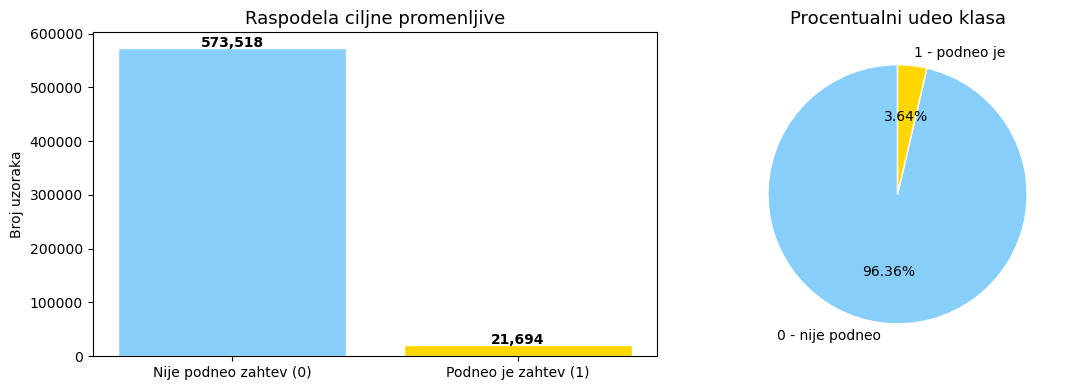


Nebalansiranost: 26.4:1 u korist klase 0


In [10]:
fig, axes = plt.subplots(1,2,figsize = (12,4))

# Numericki prikaz
counts = train['target'].value_counts()
axes[0].bar(["Nije podneo zahtev (0)", "Podneo je zahtev (1)"],
           counts.values, color = ['lightskyblue','gold'], edgecolor = 'white')
axes[0].set_title("Raspodela ciljne promenljive",fontsize = 13)
axes[0].set_ylabel('Broj uzoraka')
for i,v in enumerate(counts.values):
    axes[0].text(i,v + 500, f'{v:,}', ha ='center',fontweight = 'bold')

# Procentualni prikaz
axes[1].pie(counts.values, labels = ['0 - nije podneo', '1 - podneo je'],
           autopct='%1.2f%%', colors = ['lightskyblue','gold'],
           startangle=90, wedgeprops= {'edgecolor':'white'})
axes[1].set_title('Procentualni udeo klasa',fontsize = 13)

plt.tight_layout()
plt.show()

print(f"\nNebalansiranost: {counts[0]/counts[1]:.1f}:1 u korist klase 0")

Analiza raspodele ciljne promenljive pokazuje izraženu nebalansiranost klasa. Od ukupno 595212 uzoraka, svega oko 3.6% pripada pozitivnoj klasi (vozači koji su podneli zahtev), dok preostalih 96.4% nije podnelo zahtev.

Ovakva distribucija izlazne promenljive predstavlja izazov za klasifikacione modele, jer naivan model koji uvek predviđa većinsku klasu može postići visoku tačnost, ali bez stvarne korisnosti. Zbog toga `accuracy` nije adekvatna metrika, već će se koristiti metrike koje bolje prikazuju performanse modela na nebalansiranim podacima.

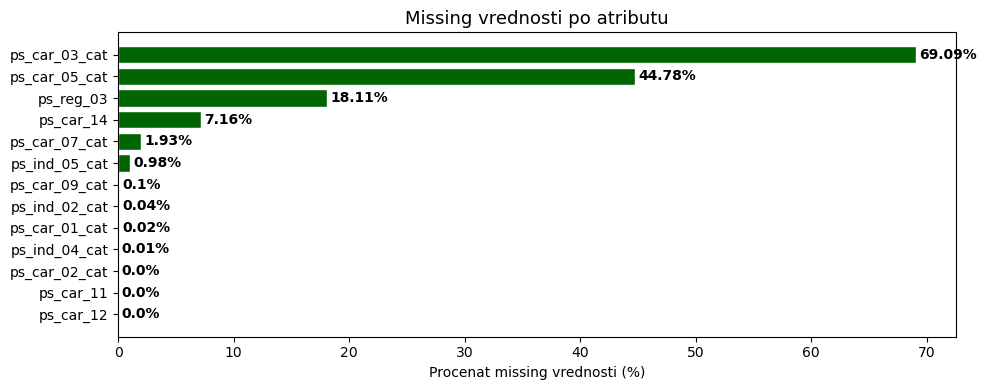

In [11]:
# Zamena -1 sa NaN samo za vizualizaciju
train_missing = train.replace(-1, np.nan)
missing = train_missing.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({
    'Broj missing': missing,
    'Procenat (%)': missing_pct
})
#print(missing_df.to_string())

# Vizualizacija
plt.figure(figsize=(10, 4))
bars = plt.barh(missing_pct.index, missing_pct.values, color='darkgreen', edgecolor='white')
plt.xlabel('Procenat missing vrednosti (%)')
plt.title('Missing vrednosti po atributu', fontsize=13)
for bar, val in zip(bars, missing_pct.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val}%', va='center', fontweight='bold')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

Na grafiku su prikazani atributi sa najvećim procentom nedostajućih vrednosti (kodiranim kao −1).

Može se uočiti da se procenat nedostajućih vrednosti značajno razlikuje između atributa:

- Atributi poput `ps_car_03_cat` i `ps_car_05_cat` imaju veoma visok udeo nedostajućih vrednosti. Visok procenat nedostajućih vrednosti u pojedinim atributima sugeriše da odsustvo informacije može biti informativno samo po sebi.
  
- Kod atributa sa umerenim procentom nedostajućih vrednosti (npr. ps_reg_03, ps_car_14), potrebno je razmotriti način obrade kako bi se očuvala informacija sadržana u podacima.

- Većina ostalih atributa ima vrlo mali procenat nedostajućih vrednosti (ispod 2%), što ukazuje da jednostavne metode imputacije verovatno neće značajno narušiti kvalitet podataka.

### 2.2.1 Analiza numeričkih atributa (target rate po binovima)

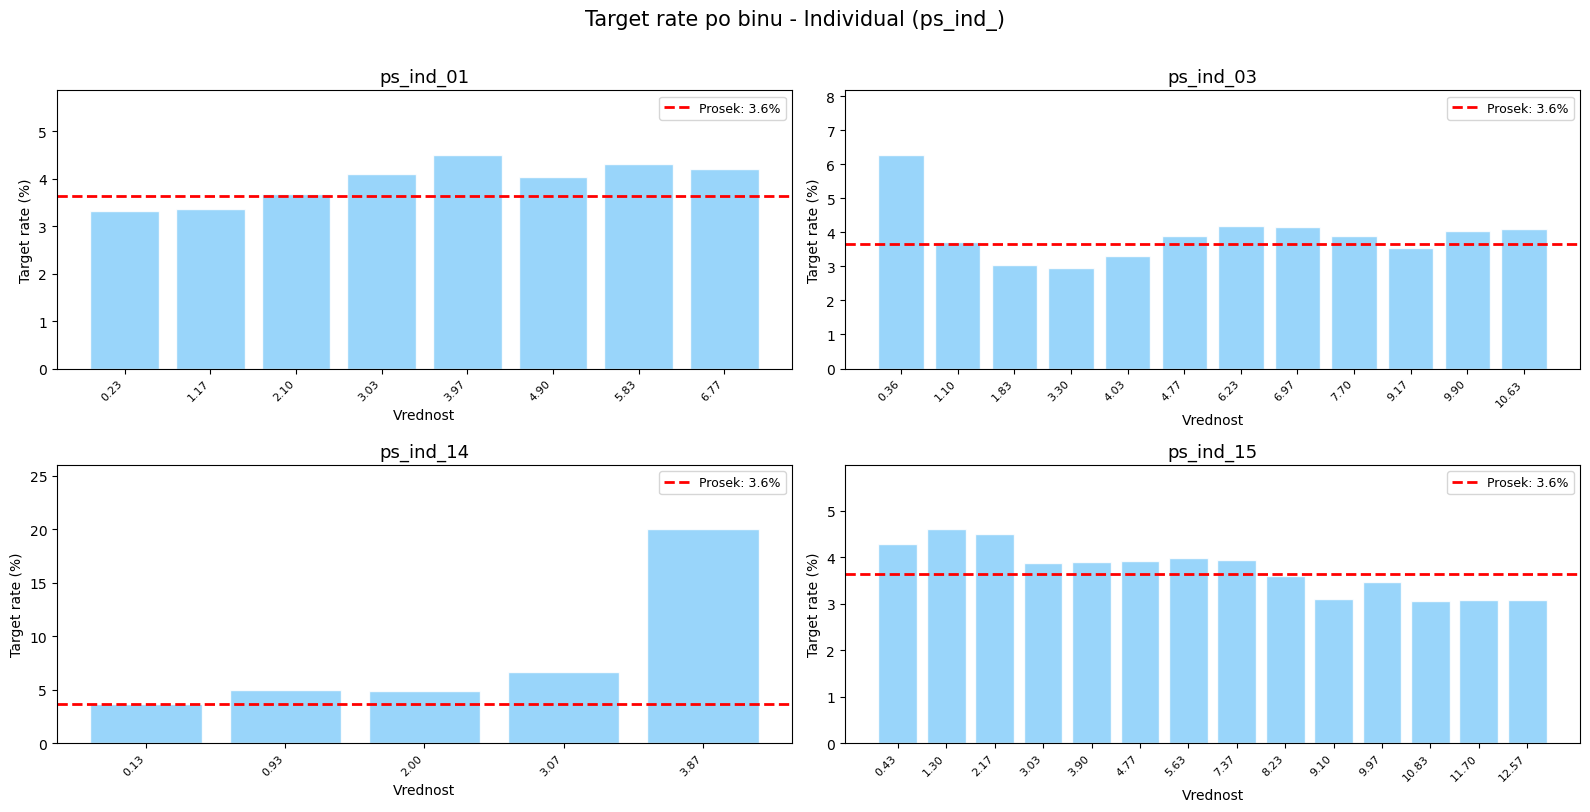

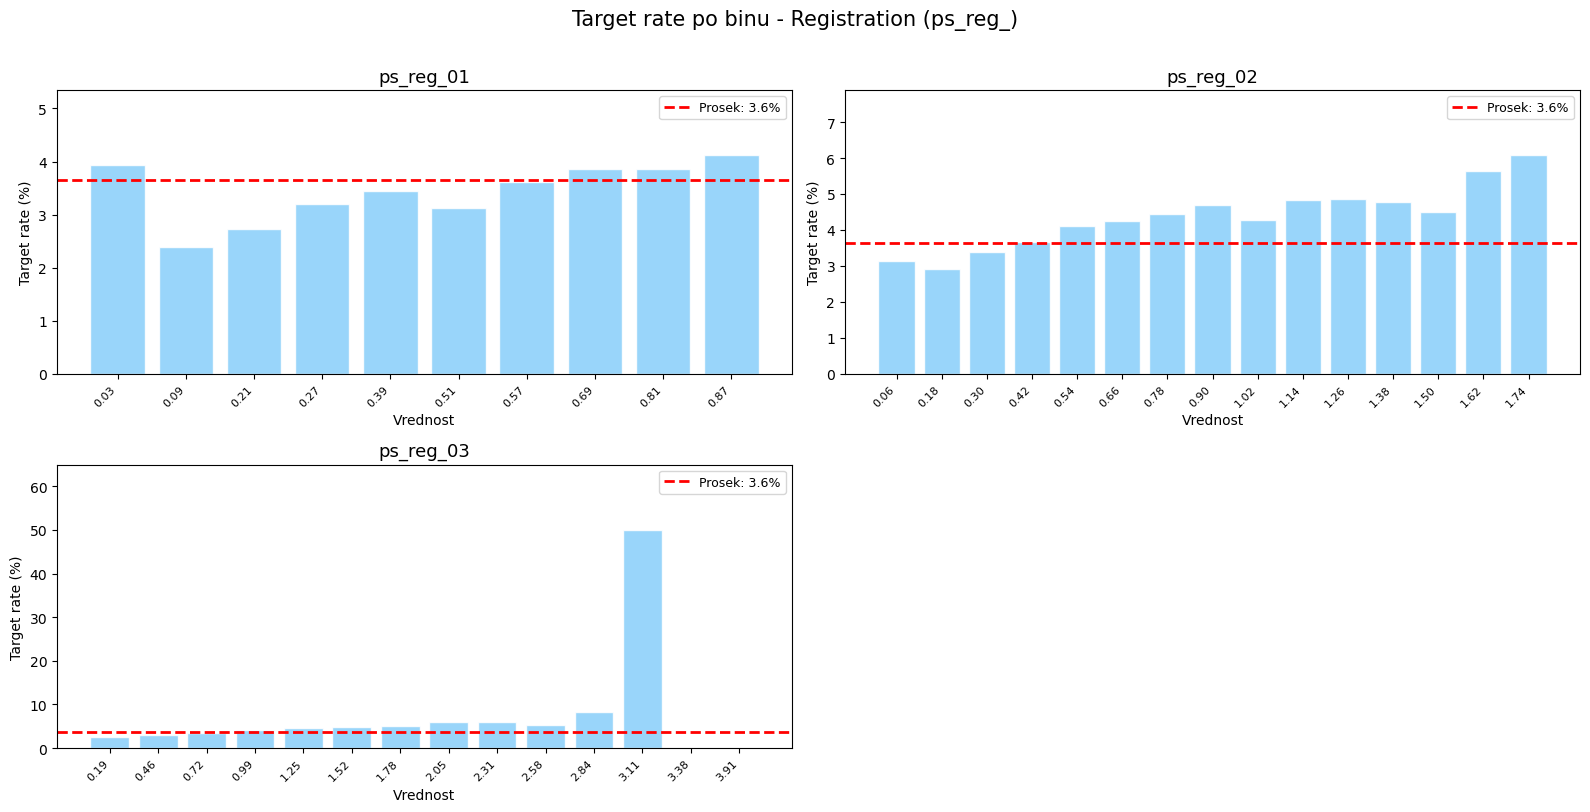

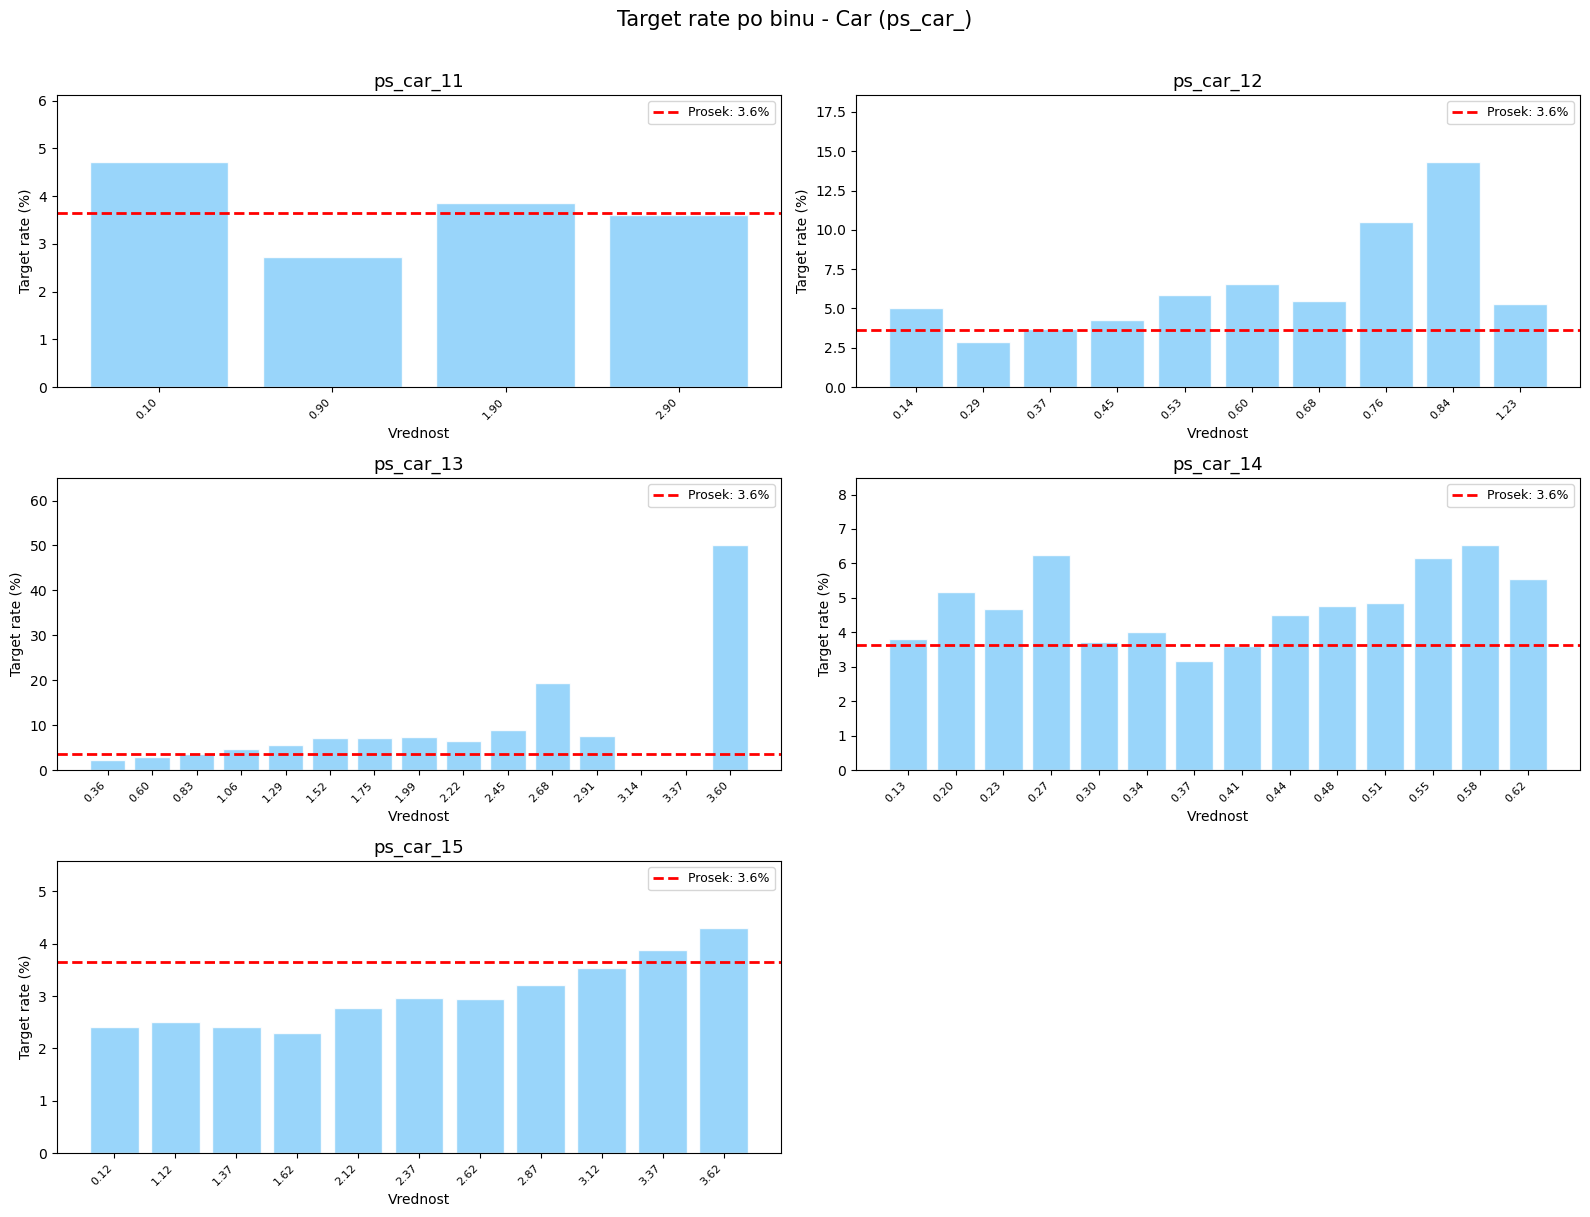

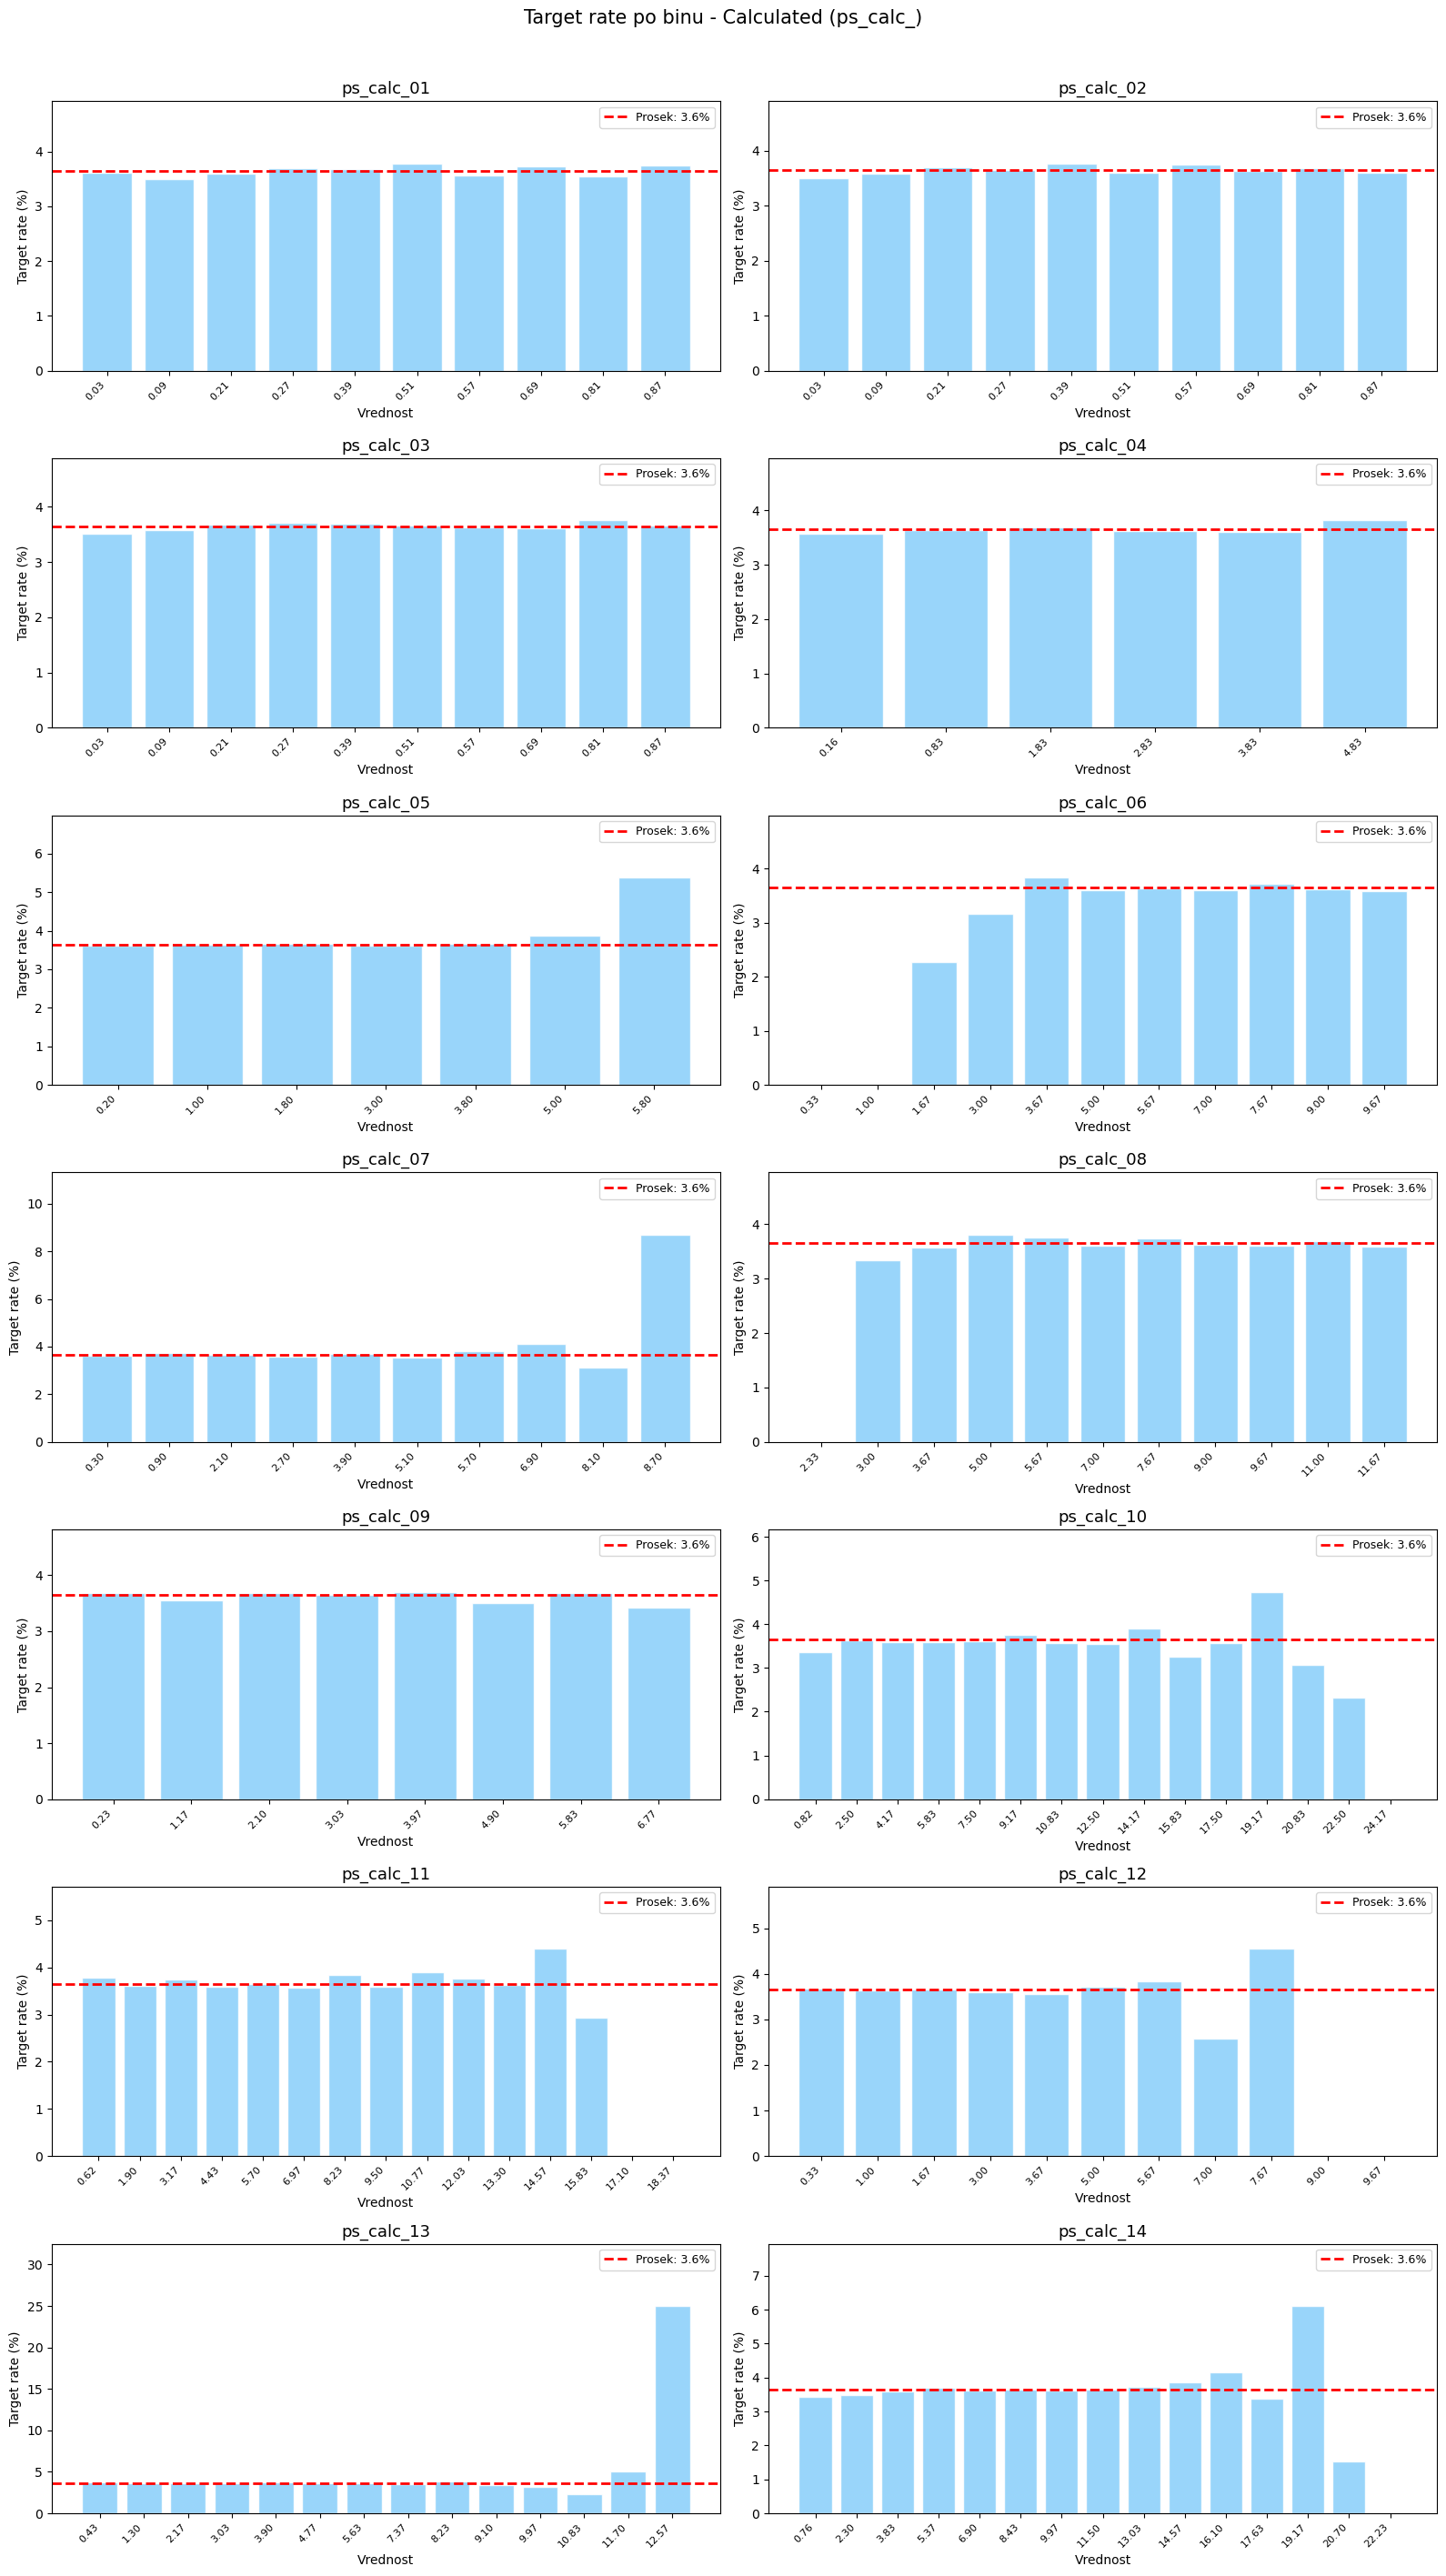

In [12]:
groups = {
    'Individual (ps_ind_)': [c for c in num_cols if c.startswith('ps_ind_')],
    'Registration (ps_reg_)': [c for c in num_cols if c.startswith('ps_reg_')],
    'Car (ps_car_)': [c for c in num_cols if c.startswith('ps_car_')],
    'Calculated (ps_calc_)': [c for c in num_cols if c.startswith('ps_calc_')]
}

global_target_rate = train['target'].mean()

for group_name, cols in groups.items():
    n_cols = 2 # Da prikažemo dve slike u redu
    n_rows = (len(cols) + n_cols - 1) // n_cols # 1-2 grafa po redu
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i, col in enumerate(cols):
        col_data = train[[col, 'target']].copy()
        col_data[col] = col_data[col].replace(-1, np.nan)
        col_data = col_data.dropna()
        
        # Deljenje vrednosti atributa u intervale (binove)
        col_data['bin'] = pd.cut(col_data[col], bins=15)
        
        # Izračunavanje target rate-a po binovima
        target_rate = col_data.groupby('bin', observed=True)['target'].mean() * 100
        
        
        bin_centers = [interval.mid for interval in target_rate.index]
        
        bars = axes[i].bar(range(len(target_rate)), target_rate.values,
                           color='lightskyblue', edgecolor='white', alpha=0.85)
        
        # Dodavanje globalne target stope radi poređenja
        axes[i].axhline(y=global_target_rate * 100, color='red', 
                        linestyle='--', linewidth=2, 
                        label=f'Prosek: {global_target_rate*100:.1f}%')
        
        # Podešavanje labela na x-osi 
        axes[i].set_xticks(range(len(target_rate)))
        axes[i].set_xticklabels(
            [f'{b:.2f}' for b in bin_centers], 
            rotation=45, ha='right', fontsize=8
        )
        
        axes[i].set_title(col, fontsize=13)
        axes[i].set_ylabel('Target rate (%)', fontsize=10)
        axes[i].set_xlabel('Vrednost', fontsize=10)
        axes[i].legend(fontsize=9)
        axes[i].set_ylim(0, max(target_rate.values) * 1.3)
    
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Target rate po binu - {group_name}', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()

U EDA fazi nedostajuće vrednosti su privremeno izbačene kako bi se analizirala distribucija realnih vrednosti, dok će u Data Preparation fazi biti posebno tretirane.

Histogrami numeričkih atributa su analizirani u cilju uvida u raspodelu vrednosti, međutim nisu uključeni u finalni prikaz jer ne pružaju jasan uvid u odnos između atributa i ciljne promenljive.

Zbog toga je fokus stavljen na target rate analizu, koja direktno prikazuje povezanost između atributa i verovatnoće pozitivne klase.

Kako bi se bolje sagledao odnos između numeričkih atributa i ciljne promenljive, analiziran je target rate po binovima. U svakom binu računa se udeo uzoraka koji pripadaju pozitivnoj klasi (`target = 1`), dok crvena isprekidana linija predstavlja globalni prosek pozitivne klase u celom skupu podataka.

Atributi kod kojih target rate po binovima odstupa od globalnog proseka mogu ukazivati na postojanje prediktivnog signala. Sa druge strane, atributi kod kojih je target rate približno konstantan kroz sve binove verovatno nose manje korisne informacije za model.



### 2.2.2 Analiza binarnih atributa

Za binarne atribute analiziran je target rate za vrednosti 0 i 1, odnosno procenat uzoraka sa vrednošću `target = 1` unutar svake od dve moguće vrednosti atributa.

Pošto binarni atributi imaju samo dve vrednosti, ovakav prikaz je pregledniji i informativniji od histograma. Atributi kod kojih postoji veća razlika između target rate-a za vrednosti 0 i 1 mogu ukazivati na prisustvo korisnog prediktivnog signala.

In [13]:
# Grupisanje po binarnim atributima i računanje target stope
bin_target_rate = pd.DataFrame()

for col in bin_cols:
    rates = train.groupby(col, observed=True)['target'].mean() * 100
    bin_target_rate[col] = rates

bin_target_rate = bin_target_rate.T
bin_target_rate.columns = [f'vrednost_{c}' for c in bin_target_rate.columns]
bin_target_rate = bin_target_rate.fillna(0)

display(bin_target_rate.round(2))

,vrednost_0,vrednost_1
ps_ind_06_bin,4.16,2.85
ps_ind_07_bin,3.27,4.73
ps_ind_08_bin,3.54,4.20
ps_ind_09_bin,3.72,3.32
ps_ind_10_bin,3.64,5.41
ps_ind_11_bin,3.64,4.57
ps_ind_12_bin,3.63,5.14
ps_ind_13_bin,3.64,5.14
ps_ind_16_bin,4.37,3.27
ps_ind_17_bin,3.39,5.52


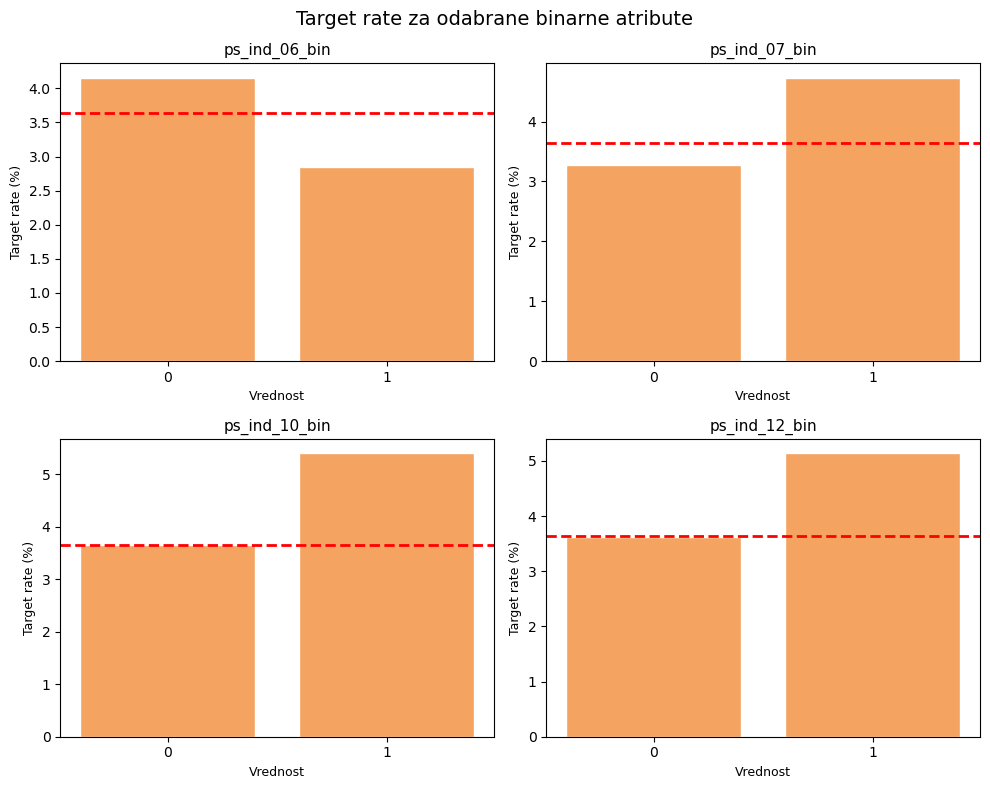

In [14]:
selected_bin = ['ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_10_bin', 'ps_ind_12_bin']

n_cols = 2
n_rows = (len(selected_bin) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 4))
axes = axes.flatten()

global_rate = train['target'].mean() * 100

for i, col in enumerate(selected_bin):
    rates = train.groupby(col, observed=True)['target'].mean() * 100
    rates = rates.reindex([0, 1], fill_value=0)

    axes[i].bar(['0', '1'], rates.values, color='sandybrown', edgecolor='white')
    axes[i].axhline(global_rate, color='red', linestyle='--', linewidth=2)

    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Target rate (%)', fontsize=9)
    axes[i].set_xlabel('Vrednost', fontsize=9)

for j in range(len(selected_bin), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Target rate za odabrane binarne atribute', fontsize=14)
plt.tight_layout()
plt.show()

Kod binarnih atributa uočava se da pojedine promenljive pokazuju razliku između target rate-a za vrednosti 0 i 1, što ukazuje da mogu sadržati određenu informaciju. Ipak, konačna procena njihovog značaja biće sprovedena kroz modele u narednim fazama.

### 2.2.3 Analiza kategoričkih atributa

Kod kategoričkih atributa analiziran je target rate po pojedinačnim kategorijama. Na ovaj način može se uočiti da li određene kategorije imaju veću ili manju verovatnoću pripadnosti pozitivnoj klasi u odnosu na globalni prosek.

Zbog velikog broja kategorijskih atributa i različitog broja kategorija po atributu, prikazani su samo određeni primeri.

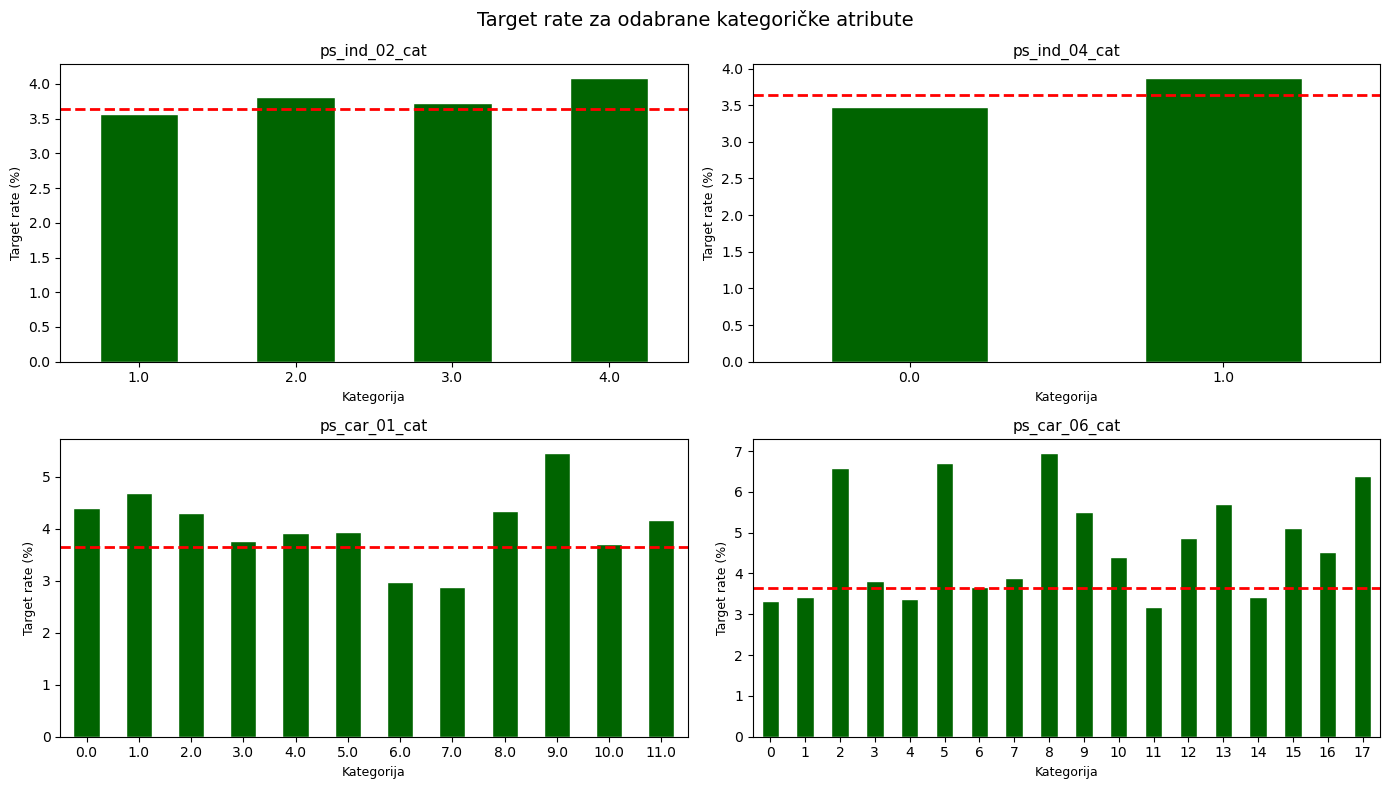

In [15]:
selected_cat = ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_car_01_cat', 'ps_car_06_cat']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

global_rate = train['target'].mean() * 100

for ax, col in zip(axes, selected_cat):
    tmp = train[[col, 'target']].copy()
    tmp[col] = tmp[col].replace(-1, np.nan)
    tmp = tmp.dropna()

    rates = tmp.groupby(col, observed=True)['target'].mean() * 100
    rates.plot(
        kind='bar',
        ax=ax,
        color='darkgreen',
        edgecolor='white'
    )

    ax.axhline(global_rate, color='red', linestyle='--', linewidth=2)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Kategorija', fontsize=9)
    ax.set_ylabel('Target rate (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Target rate za odabrane kategoričke atribute', fontsize=14)
plt.tight_layout()
plt.show()

Prikazani primeri pokazuju da i kod pojedinih kategoričkih atributa postoje razlike u target rate-u između različitih kategorija, što ukazuje na potencijalnu informativnost. Posebno treba imati u vidu da atribut `ps_car_11_cat` ima veoma veliki broj kategorija, zbog čega će u fazi pripreme podataka zahtevati poseban pristup prilikom enkodovanja.

#### 2.2.4 Korelaciona analiza numeričkih atributa

U okviru EDA faze analizirani su međusobni odnosi između numeričkih atributa. Cilj ove analize je da se identifikuju potencijalne zavisnosti između promenljivih, koje kasnije mogu poslužiti kao osnova za konstrukciju novih atributa u okviru feature engineering faze.

Zbog velikog broja atributa, prikazana je korelaciona matrica odabranih numeričkih promenljivih koje će se kasnije koristiti za konstrukciju atributa.

In [16]:
# Selektovanje numeričkih atributa
num_only_cols = [
    c for c in train.columns
    if c not in ["id", "target"] and not c.endswith("_bin") and not c.endswith("_cat")
]

# Zamena -1 sa NaN samo za potrebe korelacione matrice
train_corr = train[num_only_cols].replace(-1, np.nan)

# Pravljenje korelacione matrice
corr_matrix = train_corr.corr()

print("Dimenzije korelacione matrice:", corr_matrix.shape)
corr_matrix.head()

Dimenzije korelacione matrice: (26, 26)


,ps_ind_01,ps_ind_03,ps_ind_14,ps_ind_15,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_11,ps_car_12,ps_car_13,...,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14
ps_ind_01,1.000000,0.223408,-0.024971,0.122137,0.102212,0.183855,0.202096,0.008261,0.161880,0.099752,...,-0.001171,0.000147,-0.000658,0.002993,-0.000085,-0.001345,-0.001263,0.001521,0.000199,-0.000891
ps_ind_03,0.223408,1.000000,0.001990,0.170449,0.003209,0.048338,0.062888,-0.059340,0.089057,0.048308,...,-0.001245,0.002361,0.001533,0.001267,-0.001544,0.000230,-0.002716,-0.002352,0.000133,0.000205
ps_ind_14,-0.024971,0.001990,1.000000,-0.121547,0.014093,0.009283,0.004092,0.004415,0.019642,0.022926,...,0.000205,-0.000242,0.001023,0.004077,-0.001443,0.001976,-0.000243,0.000284,0.000307,-0.000387
ps_ind_15,0.122137,0.170449,-0.121547,1.000000,-0.051826,0.021702,0.051732,0.023035,-0.027962,-0.037885,...,0.000874,0.000033,0.001721,-0.001309,-0.000985,-0.001279,-0.001952,-0.001263,-0.000922,0.001348
ps_reg_01,0.102212,0.003209,0.014093,-0.051826,1.000000,0.471027,0.189040,0.077135,0.018782,0.027097,...,-0.000782,-0.002517,0.000424,-0.002515,0.000104,-0.001007,-0.000433,0.000968,-0.002920,-0.000177


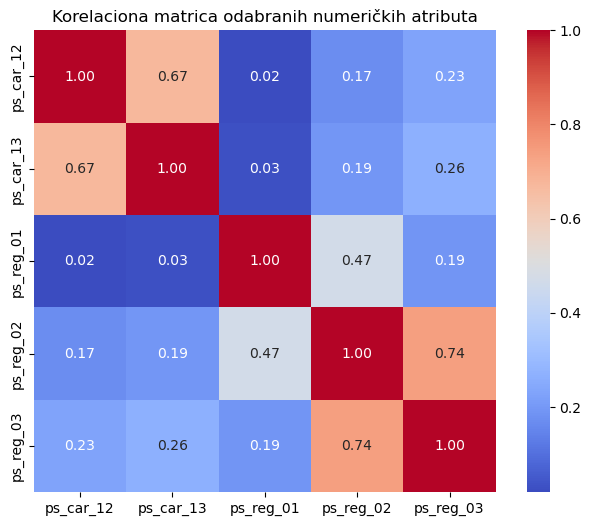

In [17]:
selected_corr_cols = ["ps_car_12", "ps_car_13", "ps_reg_01", "ps_reg_02", "ps_reg_03"]

selected_corr = train[selected_corr_cols].replace(-1, np.nan).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(selected_corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Korelaciona matrica odabranih numeričkih atributa")
plt.show()

In [18]:
# Prikaz visoko korelisanih atributa
corr_pairs = corr_matrix.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0]  # izbacivanje dijagonale
corr_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates()

print("Prikaz međusobno najkorelisanijih atributa:")
corr_pairs.head(10)

Prikaz međusobno najkorelisanijih atributa:


ps_reg_03  ps_reg_02    0.742668
ps_car_13  ps_car_12    0.672014
ps_car_14  ps_car_12    0.603361
ps_car_15  ps_car_13    0.529519
ps_reg_01  ps_reg_02    0.471027
ps_car_13  ps_car_14    0.459047
ps_reg_03  ps_car_13    0.264800
ps_car_12  ps_reg_03    0.228926
ps_ind_01  ps_ind_03    0.223408
ps_reg_03  ps_ind_01    0.202096
dtype: float64

Korelaciona analiza pokazuje da između pojedinih numeričkih atributa postoji viša korelisanost, posebno unutar istih grupa atributa (`ps_car_` i `ps_reg_`). 

Ovakvi odnosi ne znače automatski da atributi treba da budu uklonjeni, ali mogu ukazivati na to da njihove kombinacije ili interakcije nose dodatnu informaciju.

### 2.3 Zaključci analize

Na osnovu sprovedene eksploratorne analize mogu se izdvojiti sledeći ključni nalazi:

- Dataset je ekstremno nebalansiran (96.4% prema 3.6%), zbog čega accuracy nije adekvatna metrika, već su pogodnije metrike poput AUC/Gini.
- Ukupno 13 atributa sadrži nedostajuće vrednosti kodirane kao `-1`, pri čemu se posebno izdvajaju `ps_car_03_cat` i `ps_car_05_cat` sa veoma visokim procentom nedostajućih vrednosti.
- Većina atributa iz grupe `ps_calc_` pokazuje približno ravnomeran target rate, što može ukazivati na slabiji signal posmatrano pojedinačno. Međutim, njihova informativnost biće dodatno ispitana kroz modele i konstrukciju novih atributa u narednim fazama.
- Atribut `ps_car_11_cat` ima 104 kategorije, što zahteva pažljiv izbor metode enkodovanja.
- Kod pojedinih atributa uočavaju se izraženija odstupanja target rate-a od globalnog proseka, dok kod drugih razlike nisu dovoljno izražene, zbog čega će konačna procena značajnosti atributa biti sprovedena u narednim fazama.
- Kod binarnih atributa uočene su razlike u target rate-u između vrednosti 0 i 1, što ukazuje da pojedini atributi mogu nositi korisnu informaciju za predikciju.
- Kod kategorijskih atributa target rate varira između kategorija, što ukazuje na potencijalnu informativnost, ali zbog velikog broja atributa i kategorija nije moguće na osnovu same vizuelne analize doneti konačne zaključke.
- U korelacionoj matrici uočene su visoke međusobne zavisnosti između pojedinih numeričkih atributa, posebno unutar istih grupa (ps_car_ i ps_reg_). Ovi odnosi ukazuju na to da njihove kombinacije mogu nositi dodatnu informaciju, što će biti iskorišćeno u fazi Feature Engineering-a.

---
## 3. Data Preparation

U skladu sa CRISP-DM pristupom, faza pripreme podataka obuhvata sve transformacije neophodne da bi podaci bili pogodni za treniranje modela. 
U ovoj fazi cilj je da se podaci transformišu u oblik pogodan za treniranje modela. Posebna pažnja posvećena je izbegavanju curenja informacija (data leakage), zbog čega se svi koraci koji uče iz podataka, poput imputacije,  encoding-a i skaliranja, fituju isključivo na trening skupu, a zatim primenjuju na test skup.

### 3.1 Podela na trening i test skup

Pre svih transformacija koje zavise od podataka, skup je podeljen na trening i test deo. Na ovaj način obezbeđuje se da se parametri pripreme podataka određuju isključivo na trening skupu.

Podela je izvršena stratifikovano, kako bi odnos klasa ostao približno isti u oba skupa.

In [19]:
# Podela na trening i test set
X = train.drop(['id', 'target'], axis=1)
y = train['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nRaspodela target promenljive na trening delu: {y_train.value_counts(normalize=True).round(4).to_dict()}")
print(f"Raspodela target promenljive na test delu:  {y_test.value_counts(normalize=True).round(4).to_dict()}")

X_train: (476169, 57)
X_test:  (119043, 57)

Raspodela target promenljive na trening delu: {0: 0.9636, 1: 0.0364}
Raspodela target promenljive na test delu:  {0: 0.9636, 1: 0.0364}


### 3.2 Obrada atributa sa visokim procentom nedostajućih vrednosti

Kod određenih atributa sama činjenica da vrednost nedostaje može nositi dodatnu informaciju. Zbog toga je za atribute sa višim procentom nedostajućih vrednosti uveden binarni atribut koji označava prisustvo nedostajuće vrednosti (_missing).

Vrednost 1 označava da je vrednost nedostajala, dok vrednost 0 označava da je atribut bio prisutan.

In [20]:
high_missing = ['ps_car_03_cat' ,'ps_car_05_cat' ,'ps_reg_03', 'ps_car_14']

for col in high_missing:
    X_train[col + '_missing'] = (X_train[col] == -1).astype(int)
    X_test[col +'_missing'] = (X_test[col] == -1).astype(int)

In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 476169 entries, 18032 to 445856
Data columns (total 61 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ps_ind_01              476169 non-null  int64  
 1   ps_ind_02_cat          476169 non-null  int64  
 2   ps_ind_03              476169 non-null  int64  
 3   ps_ind_04_cat          476169 non-null  int64  
 4   ps_ind_05_cat          476169 non-null  int64  
 5   ps_ind_06_bin          476169 non-null  int64  
 6   ps_ind_07_bin          476169 non-null  int64  
 7   ps_ind_08_bin          476169 non-null  int64  
 8   ps_ind_09_bin          476169 non-null  int64  
 9   ps_ind_10_bin          476169 non-null  int64  
 10  ps_ind_11_bin          476169 non-null  int64  
 11  ps_ind_12_bin          476169 non-null  int64  
 12  ps_ind_13_bin          476169 non-null  int64  
 13  ps_ind_14              476169 non-null  int64  
 14  ps_ind_15              476169 non-nul

### 3.3 Obrada atributa sa niskim procentom nedostajućih vrednosti (imputacija) 

Pošto se u ovom datasetu vrednost `-1` koristi kao indikator nedostajućih podataka, ona se najpre zamenjuje sa `NaN`. Nakon toga vrši se imputacija:

- za numeričke atribute koristi se medijana, jer je robusna na ekstremne vrednosti.
- za kategoričke atribute koristi se modus

Važno je naglasiti da se vrednosti za imputaciju određuju samo na trening skupu, a zatim primenjuju i na test skupu.

In [ ]:
# Zamena vrednosti -1 sa NaN
X_train = X_train.replace(-1, np.nan)
X_test  = X_test.replace(-1, np.nan)

# Identifikacija kolona po tipu na osnovu naziva
bin_cols = [c for c in X_train.columns if c.endswith('_bin')]
cat_cols = [c for c in X_train.columns if c.endswith('_cat')]
missing_flag_cols = [c for c in X_train.columns if c.endswith('_missing')]

num_cols_current = [
    c for c in X_train.columns
    if c not in bin_cols + cat_cols + missing_flag_cols
]

cat_cols_current = [c for c in cat_cols if c in X_train.columns]

# Imputacija numeričkih kolona medijanom
num_fill_values = {}
for col in num_cols_current:
    if X_train[col].isnull().sum() > 0 or X_test[col].isnull().sum() > 0: #može se desiti da nakon podele na train i test neka nedostajuća vrednost završi samo u test delu. Zato mora da se proveri
        num_fill_values[col] = X_train[col].median()

for col, val in num_fill_values.items():
    X_train[col] = X_train[col].fillna(val)
    X_test[col]  = X_test[col].fillna(val)
    print(f"{col}: zamenjeno medijanom ({val:.4f})")

print()

# Imputacija kategoričkih kolona modusom
cat_fill_values = {}
for col in cat_cols_current:
    if X_train[col].isnull().sum() > 0 or X_test[col].isnull().sum() > 0: #ista situacija
        cat_fill_values[col] = X_train[col].mode()[0]

for col, val in cat_fill_values.items():
    X_train[col] = X_train[col].fillna(val)
    X_test[col]  = X_test[col].fillna(val)
    print(f"{col}: zamenjeno modom ({val})")

print(f"\nPreostale NaN vrednosti u X_train: {X_train.isnull().sum().sum()}")
print(f"Preostale NaN vrednosti u X_test:  {X_test.isnull().sum().sum()}")


In [23]:
#print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

### 3.4 Enkodovanje kategoričkih atributa

Većina algoritama mašinskog učenja ne može direktno da radi sa kategoričkim atributima, pa ih je potrebno prevesti u numerički oblik.

Za atribute sa manjim brojem kategorija koristi se one-hot encoding, dok se za atribut `ps_car_11_cat`, koji ima vrlo visoku kardinalnost, koristi target encoding. Ovaj pristup zamenjuje svaku kategoriju prosečnom vrednošću ciljne promenljive u trening skupu.


In [24]:
# Target encoding za atribut sa visokom kardinalnošću
high_card_col = 'ps_car_11_cat' 

te_train = pd.DataFrame({
    high_card_col: X_train[high_card_col],
    'target': y_train #samo sa trening seta
})

global_target_mean = te_train['target'].mean() # uzimamo ukupni procenat pozitivne klase na trening skupu
target_enc_map = te_train.groupby(high_card_col)['target'].mean().to_dict() # grupišemo sve redove po vrednostima kolone i računamo prosečnu vrednost targeta 

X_train[high_card_col] = X_train[high_card_col].map(target_enc_map).fillna(global_target_mean)
X_test[high_card_col]  = X_test[high_card_col].map(target_enc_map).fillna(global_target_mean)

print(f"Target encoding završen za {high_card_col}")
print(f"Primer mapiranja (prvih 5): {dict(list(target_enc_map.items())[:5])}")

Target encoding završen za ps_car_11_cat
Primer mapiranja (prvih 5): {1: 0.04452054794520548, 2: 0.03773584905660377, 3: 0.0530565167243368, 4: 0.0622598001537279, 5: 0.04123505976095618}


In [25]:
print(X_train.columns)

Index(['ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03', 'ps_ind_04_cat',
       'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin',
       'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin',
       'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15', 'ps_ind_16_bin',
       'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03',
       'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat',
       'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat',
       'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat', 'ps_car_11',
       'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01',
       'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06',
       'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11',
       'ps_calc_12', 'ps_calc_13', 'ps_calc_14', 'ps_calc_15_bin',
       'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin',
       'ps_calc_20_bin', 'ps_car_03_cat_mi

In [26]:
# One-hot encoding za preostale kategoričke atribute
remaining_cat = [c for c in cat_cols if c != high_card_col]

X_train = pd.get_dummies(X_train, columns=remaining_cat)
X_test  = pd.get_dummies(X_test, columns=remaining_cat)

# Usklađivanje kolona (align)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0) 

print(f"Broj atributa nakon enkodovanja: {X_train.shape[1]}")

Broj atributa nakon enkodovanja: 119


Nakon target enkodovanja atributa visoke kardinalnosti ps_car_11_cat, preostali kategorički atributi transformisani su primenom one-hot enkodovanja. Na taj način kategoričke vrednosti prevedene su u binarne promenljive pogodne za primenu algoritama. Nakon enkodovanja, struktura atributa između trening i test skupa može da se razlikuje zbog različitih kategorija. Zbog toga je izvršeno usklađivanje (align) kako bi oba skupa imala identične atribute, pri čemu su nedostajuće kolone u test skupu popunjene nulama.

### 3.5 Skaliranje

Skaliranje je neophodno za algoritme zasnovane na udaljenosti, kao i za modele osetljive na razlike u skali atributa, jer različiti opsezi vrednosti mogu značajno uticati na proces učenja. Za tree-based modele koristiće se neskalirana verzija podataka.
Primena je izvršena pomoću `StandardScaler` transformacije.

In [27]:
scaler = StandardScaler()

# Skalirana verzija
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(X_test_sc, columns=X_test.columns, index=X_test.index)

print("Prikaz pre i posle skaliranja.")
print(f"\n ps_car_13 pre skaliranja: mean={X_train['ps_car_13'].mean():.4f}, std={X_train['ps_car_13'].std():.4f}")
print(f"ps_car_13 posle skaliranja: mean={X_train_sc['ps_car_13'].mean():.4f}, std={X_train_sc['ps_car_13'].std():.4f}")

Prikaz pre i posle skaliranja.

 ps_car_13 pre skaliranja: mean=0.8133, std=0.2246
ps_car_13 posle skaliranja: mean=-0.0000, std=1.0000


Data Preparation je završen. Nakon pripreme podataka dobijene su dve verzije skupa:

- `X_train`, `X_test` - neskalirani skup, pogodan za tree-based modele
- `X_train_sc`, `X_test_sc` - skalirani skup, namenjen modelima poput logističke regresije i KNN-a
- `y_train`, `y_test` - ciljne promenljive

Na ovaj način podaci su pripremljeni za fazu baseline modelovanja.

In [28]:
def check_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct = outliers / len(df) * 100
        
        print(f"{col}: {outliers} ({pct:.2f}%)")

# Prikaz nekoliko numeričkih kolona
check_outliers(X_train, ['ps_car_13', 'ps_reg_03', 'ps_car_14'])

ps_car_13: 21518 (4.52%)
ps_reg_03: 28446 (5.97%)
ps_car_14: 24205 (5.08%)


Analizom raspodele numeričkih atributa i primenom IQR metode identifikovani su potencijalni outlieri. Uočeno je da pojedine varijable pokazuju blagu asimetriju (skewness), ali bez prisustva ekstremnih vrednosti koje značajno odstupaju od ostatka distribucije.

Razmatrane su različite strategije tretiranja outliera (uklanjanje, winsorizacija, imputacija), ali je zaključeno da bi takve transformacije mogle dovesti do gubitka informacija.

Zbog toga outlieri nisu eksplicitno tretirani, već je njihov uticaj ublažen primenom StandardScaler-a kod modela osetljivih na skalu atributa.

Iako bi u slučaju izraženijih odstupanja RobustScaler bio adekvatniji izbor, u ovom slučaju njegova primena nije bila neophodna.
    

## 4. Baseline Modeling

U ovoj fazi treniraju se osnovni klasifikacioni modeli kako bi se uspostavila početna referenca performansi. 
Cilj baseline modela nije postizanje optimalnih rezultata, već definisanje polazne tačke
na osnovu koje će se kasnije meriti efekti feature engineering-a, selekcije atributa 
i optimizacije hiperparametara.

Kao mera performansi koristiće se već navedena normalized gini metrika.

U okviru baseline analize koristiće se sledeći modeli:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree

In [29]:
def evaluate_model(name, y_true, y_pred):
    auc = roc_auc_score(y_true, y_pred)
    gini = 2 * auc - 1
    
    print(f"{name}")
    print(f"AUC:  {auc:.4f}")
    print(f"Gini: {gini:.4f}")
    
    return auc, gini

### 4.1 Logistic Regression

Logistic Regression predstavlja linearan model koji procenjuje verovatnoću 
pripadnosti pozitivnoj klasi koristeći logističku funkciju. 

Ovaj model je osetljiv na skalu atributa, zbog čega se trenira nad skaliranim podacima.

In [30]:
# Inicijalizacija modela
lr = LogisticRegression(max_iter=1000, random_state=7)

# Treniranje modela na skaliranim podacima
lr.fit(X_train_sc, y_train)

# Izračunavanje verovatnoće pripadnosti pozitivnoj klasi
y_pred_lr = lr.predict_proba(X_test_sc)[:, 1]

# Evaluacija modela pomoću AUC i Gini metrika
auc_lr, gini_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr)


Logistic Regression
AUC:  0.6386
Gini: 0.2772


ROC-AUC vrednost predstavlja sposobnost modela da razlikuje 
pozitivnu i negativnu klasu nezavisno od praga odlučivanja.

### 4.2 K-Nearest Neighbors (KNN)

KNN je model zasnovan na udaljenosti između uzoraka. 
Za klasifikaciju koristi većinsko glasanje najbližih suseda.

Pošto koristi mere udaljenosti, izuzetno je osetljiv na skalu atributa, 
zbog čega se trenira nad skaliranim podacima.

In [31]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_sc, y_train)

y_pred_knn = knn.predict_proba(X_test_sc)[:, 1]

auc_knn, gini_knn = evaluate_model("KNN", y_test, y_pred_knn)

KNN
AUC:  0.5191
Gini: 0.0382


### 4.3 Decision Tree

Decision Tree je nelinearni model koji ne zahteva skaliranje atributa, 
pa se trenira nad originalnim podacima. Sklon је overfittingu, ukoliko se ne ograniči.

In [32]:
dt = DecisionTreeClassifier(random_state=7)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict_proba(X_test)[:, 1]

auc_dt, gini_dt = evaluate_model("Decision Tree", y_test, y_pred_dt)

Decision Tree
AUC:  0.5084
Gini: 0.0167


### 4.4 Poređenje baseline modela

U nastavku su prikazane AUC i Gini vrednosti svih treniranih baseline modela.

In [33]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "AUC": [auc_lr, auc_knn, auc_dt],
    "Gini": [gini_lr, gini_knn, gini_dt]
})

results.sort_values(by="Gini", ascending=False)

,Model,AUC,Gini
0,Logistic Regression,0.638582,0.277165
1,KNN,0.519119,0.038238
2,Decision Tree,0.508355,0.016710


Na osnovu dobijenih rezultata može se uočiti da Logistic Regression predstavlja najjači baseline model, dok KNN i Decision Tree postižu znatno slabije performanse. 


## 5. Feature Engineering

U ovoj fazi cilj je konstruisanje novih atributa koji bi mogli bolje da otkriju obrasce u podacima od originalnih ulaznih promenljivih.

Pošto je dataset anoniman, ne postoji domensko znanje o konkretnim atributima pa se feature engineering se ovde zasniva pre svega na:
- Informacije o nedostajućim vrednostima - sama činjenica da vrednost 
  nedostaje može biti prediktivna (npr. klijenti koji nisu prijavili 
  određene podatke mogu imati specifičan rizični profil).
- Agregirane statistike po grupama atributa - umesto da model sam 
  nauči odnos između desetina srodnih atributa, dajemo mu sintetizovanu 
  vrednost (zbir, prosek) po semantičkoj grupi (ind, reg, car, calc).
- Interakcije između numeričkih atributa - linearni modeli ne mogu 
  sami da otkriju da kombinacija dve vrednosti nosi informaciju; 
  množenjem atributa eksplicitno uvodimo tu nelinearnost.

Nakon kreiranja novih atributa, njihova korisnost će biti procenjena kroz poređenje performansi baseline modela pre i posle feature engineering-a.

In [34]:
# Rad na kopijama podataka
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

In [35]:
# Broj nedostajućih vrednosti po redu na osnovu originalne -1 konvencije
X_train_fe["fe_missing_count"] = (train.loc[X_train.index].drop(columns=["id", "target"]) == -1).sum(axis=1)
X_test_fe["fe_missing_count"] = (train.loc[X_test.index].drop(columns=["id", "target"]) == -1).sum(axis=1)

Pošto su sve `-1` vrednosti u fazi pripreme podataka zamenjene sa `NaN`,
vraćamo se na originalni train DataFrame kako bismo prebrojali koliko je
originalno nedostajućih vrednosti imao svaki red.

Hipoteza je da klijenti sa više nepoznatih vrednosti u profilu mogu
imati drugačije reagovati na rizik. Sam nedostatak podataka može biti
signal za model.

In [36]:
# Zbir svih binarnih atributa po redu
bin_cols = [c for c in X_train.columns if c.endswith("_bin")]

X_train_fe["fe_bin_sum"] = X_train_fe[bin_cols].sum(axis=1)
X_test_fe["fe_bin_sum"] = X_test_fe[bin_cols].sum(axis=1)

In [37]:
# Zbir binarnih atributa po grupama
ind_bin_cols = [c for c in bin_cols if c.startswith("ps_ind_")]
calc_bin_cols = [c for c in bin_cols if c.startswith("ps_calc_")]

X_train_fe["fe_ind_bin_sum"] = X_train_fe[ind_bin_cols].sum(axis=1)
X_test_fe["fe_ind_bin_sum"] = X_test_fe[ind_bin_cols].sum(axis=1)

X_train_fe["fe_calc_bin_sum"] = X_train_fe[calc_bin_cols].sum(axis=1)
X_test_fe["fe_calc_bin_sum"] = X_test_fe[calc_bin_cols].sum(axis=1)

Binarni atributi su grupisani i sabrani po grupama. Za svaki red izračunat je broj atributa sa vrednošću 1, kao i broj takvih atributa po grupama.

In [38]:
# Agregiranje po grupama za numeričke atribute
num_only_cols = [c for c in X_train.columns if not c.endswith("_bin") and not c.endswith("_cat")]

ind_num_cols = [c for c in num_only_cols if c.startswith("ps_ind_")]
reg_num_cols = [c for c in num_only_cols if c.startswith("ps_reg_")]
car_num_cols = [c for c in num_only_cols if c.startswith("ps_car_")]
calc_num_cols = [c for c in num_only_cols if c.startswith("ps_calc_")]

Numerički atributi su podeljeni u četiri semantičke grupe prema naming 
konvenciji: `ps_ind_`, `ps_reg_`, `ps_car_` i `ps_calc_`. Za svaku grupu 
izračunat su prosek i standardna devijacija po svakoj opservaciji kao novi atributi.

In [39]:
# Srednja vrednost po grupama
X_train_fe["fe_ind_num_mean"] = X_train_fe[ind_num_cols].mean(axis=1)
X_test_fe["fe_ind_num_mean"] = X_test_fe[ind_num_cols].mean(axis=1)

X_train_fe["fe_reg_num_mean"] = X_train_fe[reg_num_cols].mean(axis=1)
X_test_fe["fe_reg_num_mean"] = X_test_fe[reg_num_cols].mean(axis=1)

X_train_fe["fe_car_num_mean"] = X_train_fe[car_num_cols].mean(axis=1)
X_test_fe["fe_car_num_mean"] = X_test_fe[car_num_cols].mean(axis=1)

X_train_fe["fe_calc_num_mean"] = X_train_fe[calc_num_cols].mean(axis=1)
X_test_fe["fe_calc_num_mean"] = X_test_fe[calc_num_cols].mean(axis=1)

In [40]:
# Standardna devijacija po grupama
X_train_fe["fe_ind_num_std"] = X_train_fe[ind_num_cols].std(axis=1)
X_test_fe["fe_ind_num_std"] = X_test_fe[ind_num_cols].std(axis=1)

X_train_fe["fe_reg_num_std"] = X_train_fe[reg_num_cols].std(axis=1)
X_test_fe["fe_reg_num_std"] = X_test_fe[reg_num_cols].std(axis=1)

X_train_fe["fe_car_num_std"] = X_train_fe[car_num_cols].std(axis=1)
X_test_fe["fe_car_num_std"] = X_test_fe[car_num_cols].std(axis=1)

X_train_fe["fe_calc_num_std"] = X_train_fe[calc_num_cols].std(axis=1)
X_test_fe["fe_calc_num_std"] = X_test_fe[calc_num_cols].std(axis=1)

In [41]:
X_train_fe["fe_car12_x_car13"] = X_train_fe["ps_car_12"] * X_train_fe["ps_car_13"]
X_test_fe["fe_car12_x_car13"] = X_test_fe["ps_car_12"] * X_test_fe["ps_car_13"]

X_train_fe["fe_reg01_x_reg03"] = X_train_fe["ps_reg_01"] * X_train_fe["ps_reg_03"] #
X_test_fe["fe_reg01_x_reg03"] = X_test_fe["ps_reg_01"] * X_test_fe["ps_reg_03"]

X_train_fe["fe_reg02_x_reg03"] = X_train_fe["ps_reg_02"] * X_train_fe["ps_reg_03"]
X_test_fe["fe_reg02_x_reg03"] = X_test_fe["ps_reg_02"] * X_test_fe["ps_reg_03"]

X_train_fe["fe_car12_x_car14"] = X_train_fe["ps_car_12"] * X_train_fe["ps_car_14"]
X_test_fe["fe_car12_x_car14"] = X_test_fe["ps_car_12"] * X_test_fe["ps_car_14"]

X_train_fe["fe_car13_x_car15"] = X_train_fe["ps_car_13"] * X_train_fe["ps_car_15"]
X_test_fe["fe_car13_x_car15"] = X_test_fe["ps_car_13"] * X_test_fe["ps_car_15"]

Kreirani su novi atributi množenjem odabranih parova atributa, čime se 
modeluje interakcija između njih.

In [42]:
print("Originalan broj atributa:", X_train.shape[1])
print("Broj atributa nakon feature engineering-a:", X_train_fe.shape[1])

Originalan broj atributa: 119
Broj atributa nakon feature engineering-a: 136


In [43]:
X_train_fe.describe()
#X_train_fe.describe(include='all')

,ps_ind_01,ps_ind_03,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,...,fe_calc_bin_sum,fe_reg_num_mean,fe_calc_num_mean,fe_reg_num_std,fe_calc_num_std,fe_car12_x_car13,fe_reg01_x_reg03,fe_reg02_x_reg03,fe_car12_x_car14,fe_car13_x_car15
count,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,...,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000,476169.000000
mean,1.898374,4.420720,0.394070,0.256989,0.163980,0.184962,0.000342,0.001733,0.009482,0.000966,...,2.093767,0.527021,3.828381,0.431709,3.524834,0.317789,0.554495,0.477481,0.143801,2.580515
std,1.982817,2.698591,0.488651,0.436974,0.370257,0.388267,0.018499,0.041588,0.096913,0.031066,...,1.072803,0.189775,0.428721,0.125310,0.494415,0.136892,0.377932,0.628988,0.036268,1.064431
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.080768,2.057143,0.081014,1.660944,0.086582,0.000000,0.000000,0.031032,0.000000
25%,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.401941,3.535714,0.356196,3.183241,0.224607,0.262679,0.111915,0.116619,1.948850
50%,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.508603,3.821429,0.408359,3.490301,0.288101,0.497494,0.240468,0.142969,2.528709
75%,3.000000,6.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,0.605410,4.114286,0.469375,3.829362,0.366263,0.752247,0.568683,0.160549,3.159058
max,7.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,6.000000,1.684486,5.935714,1.732534,6.693264,2.517608,3.634151,7.268301,0.453900,13.921308


In [44]:
scaler_fe = StandardScaler()

X_train_fe_sc = pd.DataFrame(
    scaler_fe.fit_transform(X_train_fe),
    columns=X_train_fe.columns,
    index=X_train_fe.index
)

X_test_fe_sc = pd.DataFrame(
    scaler_fe.transform(X_test_fe),
    columns=X_test_fe.columns,
    index=X_test_fe.index
)

In [45]:
X_train_fe_sc.describe()

,ps_ind_01,ps_ind_03,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,...,fe_calc_num_mean,fe_ind_num_std,fe_reg_num_std,fe_car_num_std,fe_calc_num_std,fe_car12_x_car13,fe_reg01_x_reg03,fe_reg02_x_reg03,fe_car12_x_car14,fe_car13_x_car15
count,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,...,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05,4.761690e+05
mean,-8.356359e-18,-1.898087e-16,-2.793412e-17,-7.926604e-17,-6.326958e-18,4.524372e-17,5.730075e-18,2.086105e-17,-3.605172e-17,3.402232e-18,...,6.849230e-16,7.932573e-17,3.656803e-16,-1.739018e-15,4.198474e-16,1.586515e-16,1.665303e-16,-1.378799e-17,-6.701800e-16,-1.513695e-16
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-9.574136e-01,-1.638160e+00,-8.064466e-01,-5.881108e-01,-4.428804e-01,-4.763781e-01,-1.850494e-02,-4.166035e-02,-9.784015e-02,-3.109627e-02,...,-4.131453e+00,-2.313889e+00,-2.798623e+00,-3.909598e+00,-3.769894e+00,-1.688974e+00,-1.467184e+00,-7.591274e-01,-3.109279e+00,-2.424316e+00
25%,-9.574136e-01,-8.970321e-01,-8.064466e-01,-5.881108e-01,-4.428804e-01,-4.763781e-01,-1.850494e-02,-4.166035e-02,-9.784015e-02,-3.109627e-02,...,-6.826525e-01,-6.584005e-01,-6.026114e-01,-5.457982e-01,-6.909055e-01,-6.806938e-01,-7.721408e-01,-5.811982e-01,-7.494658e-01,-5.934301e-01
50%,-4.530802e-01,-1.559039e-01,-8.064466e-01,-5.881108e-01,-4.428804e-01,-4.763781e-01,-1.850494e-02,-4.166035e-02,-9.784015e-02,-3.109627e-02,...,-1.621766e-02,-1.040055e-02,-1.863372e-01,2.137469e-01,-6.984818e-02,-2.168708e-01,-1.508234e-01,-3.768170e-01,-2.295315e-02,-4.867006e-02
75%,5.555867e-01,5.852243e-01,1.240008e+00,1.700360e+00,-4.428804e-01,-4.763781e-01,-1.850494e-02,-4.166035e-02,-9.784015e-02,-3.109627e-02,...,6.668780e-01,7.266875e-01,3.005824e-01,7.819351e-01,6.159351e-01,3.541078e-01,5.232488e-01,1.449972e-01,4.617802e-01,5.435239e-01
max,2.572920e+00,2.438045e+00,1.240008e+00,1.700360e+00,2.257946e+00,2.099173e+00,5.403964e+01,2.400364e+01,1.022075e+01,3.215820e+01,...,4.915400e+00,2.552109e+00,1.038086e+01,3.206509e+00,6.408448e+00,1.606974e+01,8.148721e+00,1.079644e+01,8.550096e+00,1.065433e+01


In [46]:
# Logistic Regression na FE datasetu
lr_fe = LogisticRegression(max_iter=1000, random_state=7)
lr_fe.fit(X_train_fe_sc, y_train)
y_pred_lr_fe = lr_fe.predict_proba(X_test_fe_sc)[:, 1]
auc_lr_fe, gini_lr_fe = evaluate_model("Logistic Regression (FE)", y_test, y_pred_lr_fe)

Logistic Regression (FE)
AUC:  0.6406
Gini: 0.2811


In [47]:
# KNN na FE datasetu
knn_fe = KNeighborsClassifier(n_neighbors=5)
knn_fe.fit(X_train_fe_sc, y_train)
y_pred_knn_fe = knn_fe.predict_proba(X_test_fe_sc)[:, 1]
auc_knn_fe, gini_knn_fe = evaluate_model("KNN (FE)", y_test, y_pred_knn_fe)

KNN (FE)
AUC:  0.5203
Gini: 0.0405


In [48]:
# Decision Tree na FE datasetu
dt_fe = DecisionTreeClassifier(random_state=7)
dt_fe.fit(X_train_fe, y_train)
y_pred_dt_fe = dt_fe.predict_proba(X_test_fe)[:, 1]
auc_dt_fe, gini_dt_fe = evaluate_model("Decision Tree (FE)", y_test, y_pred_dt_fe)

Decision Tree (FE)
AUC:  0.5083
Gini: 0.0166


In [49]:
fe_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "AUC_FE": [auc_lr_fe, auc_knn_fe, auc_dt_fe],
    "Gini_FE": [gini_lr_fe, gini_knn_fe, gini_dt_fe]
})

comparison = results.merge(fe_results, on="Model", how="inner")


comparison.sort_values(by="Gini_FE", ascending=False)

,Model,AUC,Gini,AUC_FE,Gini_FE
0,Logistic Regression,0.638582,0.277165,0.640551,0.281102
1,KNN,0.519119,0.038238,0.520254,0.040507
2,Decision Tree,0.508355,0.016710,0.508282,0.016564


### 5.1 Zaključak Feature Engineering-a

Novokreirani atributi doveli su do poboljšanja performansi, pri čemu je najizraženiji napredak ostvaren kod logističke regresije, dok su kod KNN-a i stabla odlučivanja  ostvarena manja poboljšanja. To ukazuje da kreirani atributi nose dodatnu značajnu informaciju, ali da njihov efekat zavisi od tipa modela.

Ovakav rezultat je smislen u kontekstu Porto Seguro skupa podataka, koji je anoniman, pa je feature engineering morao biti zasnovan pre svega na strukturi podataka, a ne na domenskom značenju atributa.

Pošto se nakon feature engineering-a i dalje zadržava veći broj atributa, sledeći korak predstavlja selekcija atributa, kako bi se izdvojili najrelevantniji atributi koji će mogu dovesti do dodatnog unapređenja performansi modela.

## 6. Feature Selection

Nakon faze feature engineering-a broj atributa je dodatno povećan u odnosu na početni skup podataka. Iako veći broj atributa može omogućiti modelima da uhvate složenije obrasce u podacima, nisu svi atributi jednako korisni za predikciju ciljne promenljive. Neki atributi nose snažan prediktivni signal, dok drugi mogu biti redundantni, slabo informativni ili predstavljati šum.

Prisustvo velikog broja manje relevantnih atributa može negativno uticati na performanse modela, posebno kod jednostavnijih algoritama kao što su logistička regresija i KNN. Zbog toga je u ovoj fazi sprovedena selekcija atributa sa ciljem da se izdvoje oni atributi koji najviše doprinose predikciji.

U ovoj sekciji biće primenjena tri pristupa selekciji atributa:

- **Filter metode** - zasnovane na statističkoj povezanosti atributa sa ciljnom promenljivom, nezavisno od konkretnog modela  
- **Embedded metode** - zasnovane na proceni značaja atributa tokom samog procesa treniranja modela  
- **Wrapper metode** - zasnovane na iterativnom izboru podskupa atributa na osnovu performansi konkretnog modela  

Cilj ove sekcije je da se, primenom različitih pristupa selekcije, izdvoje najrelevantniji atributi i formira redukovani skup za dalje unapređenje modela.

## 6.1 Filter metoda

Filter metode selekcije atributa procenjuju značaj svakog atributa pojedinačno u odnosu na ciljnu promenljivu, nezavisno od konkretnog modela. Za razliku od drugih pristupa, ove metode ne uključuju treniranje modela, zbog čega su računski veoma efikasne i pogodne kao prvi korak u redukciji dimenzionalnosti.

U ovom radu koristi se metoda **SelectKBest** u kombinaciji sa funkcijom **mutual_info_classif**, koja meri količinu informacija koju atribut nosi o ciljnoj promenljivoj. Za razliku od linearnih mera (npr. korelacije ili ANOVA F-test), mutual information može da detektuje i nelinearne zavisnosti između atributa i targeta, što je posebno korisno u kompleksnijim skupovima podataka.

Cilj ove analize je da se identifikuju atributi sa najvećim informativnim značajem, odnosno oni koji najviše doprinose razdvajanju klasa. Dobijeni rezultati će biti prikazani grafički, a najrelevantniji atributi će biti korišćeni u narednim fazama.

In [50]:
# Broj atributa koje želimo da zadržimo za dalju analizu
k_filter = 30

# Primena SelectKBest metode sa mutual information metrikom
selector_filter = SelectKBest(
    score_func=lambda X, y: mutual_info_classif(X, y, random_state=7),
    k=k_filter
)
# Izračunavanje MI skora za sve atribute
selector_filter.fit(X_train_fe_sc, y_train) 

# Skorovi svih atributa
filter_scores = pd.DataFrame({
    "Feature": X_train_fe_sc.columns,
    "MI_Score": selector_filter.scores_
}).sort_values(by="MI_Score", ascending=False)

filter_scores.head(20)

,Feature,MI_Score
49,ps_ind_02_cat_2.0,0.051902
45,ps_car_05_cat_missing,0.051663
40,ps_calc_17_bin,0.051553
100,ps_car_06_cat_11,0.051346
3,ps_ind_07_bin,0.050385
2,ps_ind_06_bin,0.050088
113,ps_car_09_cat_2.0,0.049906
52,ps_ind_04_cat_0.0,0.049845
88,ps_car_05_cat_1.0,0.049795
87,ps_car_05_cat_0.0,0.049734


Vrednost MI_Score atributa nam govori koliko informacije taj atribut nosi o targetu (izlaznoj promenljivoj). Veći broj nam govori da je veza sa targetom jača. Mutual information nam ne govori da li je ta veza pozitivna ili negativna nego kolika je informativnost. 

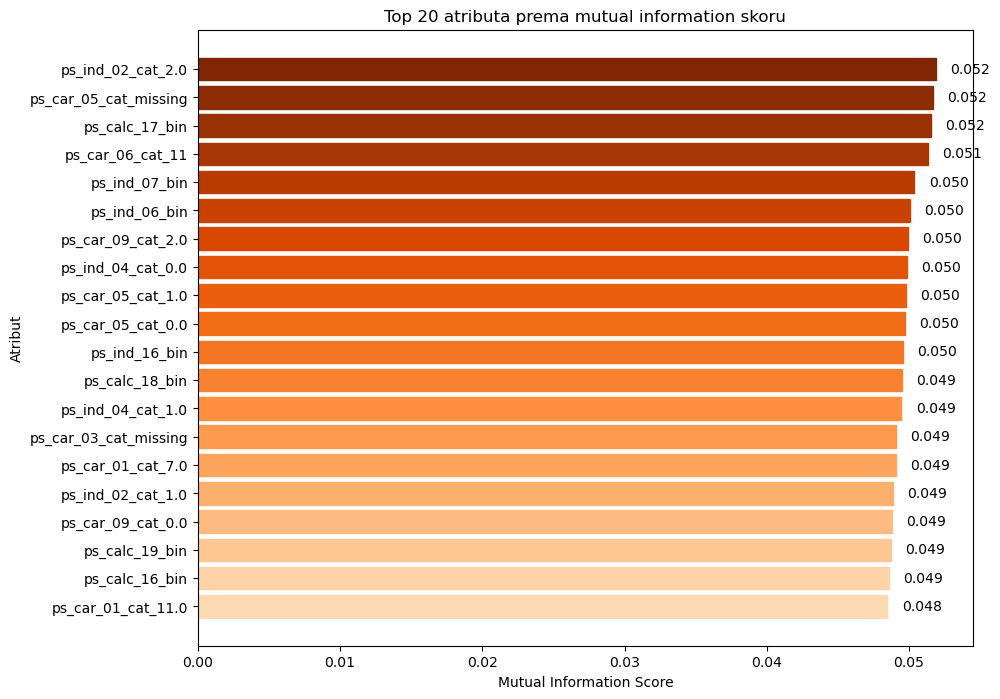

In [51]:
top_n_plot = 20
top_filter_scores = filter_scores.head(top_n_plot).sort_values(by="MI_Score", ascending=True)

plt.figure(figsize=(10, 8))
bars = plt.barh(top_filter_scores["Feature"], top_filter_scores["MI_Score"])

colors = plt.cm.Oranges(np.linspace(0.2, 1, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)
    
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}", va='center')

plt.title(f"Top {top_n_plot} atributa prema mutual information skoru")
plt.xlabel("Mutual Information Score")
plt.ylabel("Atribut")

plt.show()

Sa grafika uočavamo da su mutual information skorovi relativno ujednačeni među vodećim atributima, što ukazuje da ne postoji jedan dominantan atribut već više atributa sa sličnim značajem u pogledu izlazne varijable

In [52]:
top_k_features_filter = filter_scores.head(k_filter)["Feature"].tolist()

print(f"Broj izabranih atributa (filter metoda): {len(top_k_features_filter)}")
print("\nTop atributi prema filter metodi:")
print(top_k_features_filter)

Broj izabranih atributa (filter metoda): 30

Top atributi prema filter metodi:
['ps_ind_02_cat_2.0', 'ps_car_05_cat_missing', 'ps_calc_17_bin', 'ps_car_06_cat_11', 'ps_ind_07_bin', 'ps_ind_06_bin', 'ps_car_09_cat_2.0', 'ps_ind_04_cat_0.0', 'ps_car_05_cat_1.0', 'ps_car_05_cat_0.0', 'ps_ind_16_bin', 'ps_calc_18_bin', 'ps_ind_04_cat_1.0', 'ps_car_03_cat_missing', 'ps_car_01_cat_7.0', 'ps_ind_02_cat_1.0', 'ps_car_09_cat_0.0', 'ps_calc_19_bin', 'ps_calc_16_bin', 'ps_car_01_cat_11.0', 'ps_car_06_cat_1', 'ps_car_06_cat_0', 'ps_ind_09_bin', 'ps_reg_03_missing', 'ps_car_02_cat_1.0', 'ps_car_02_cat_0.0', 'ps_car_04_cat_0', 'ps_car_08_cat_0', 'ps_ind_08_bin', 'ps_car_08_cat_1']


In [53]:
X_train_filter = X_train_fe_sc[top_k_features_filter].copy()
X_test_filter = X_test_fe_sc[top_k_features_filter].copy()

print("Dimenzije originalnog FE skupa:", X_train_fe_sc.shape, X_test_fe_sc.shape)
print("Dimenzije nakon filter selekcije:", X_train_filter.shape, X_test_filter.shape)

Dimenzije originalnog FE skupa: (476169, 136) (119043, 136)
Dimenzije nakon filter selekcije: (476169, 30) (119043, 30)


Vrednosti MI skorova su relativno ujednačene, bez jednog dominantnog atributa koji bi daleko nadmašivao ostale. To ukazuje da je prediktivni signal raspoređen kroz više atributa. Zanimljivo je da se među najznačajnijim atributima po MI skoru nalaze i neki od missing atributa kreiranih u fazi pripreme podataka, što dodatno potvrđuje da informacija o nedostajućim vrednostima može biti korisna za predikciju.

U nastavku se, radi poređenja različitih pristupa selekciji atributa, primenjuju embedded i wrapper metode.

## 6.2 Embedded metoda: Random Forest

Za razliku od filter metoda koje posmatraju svaki atribut nezavisno, embedded metode procenjuju značaj atributa tokom samog procesa treniranja modela.

U ovom radu koristi se Random Forest model, koji omogućava procenu važnosti atributa na osnovu njihovog doprinosa smanjenju nečistoće (impurity) u stablu odlučivanja. Ova metoda uzima u obzir međusobne interakcije između atributa i može detektovati kompleksnije odnose u podacima.

Analiza se vrši nad celokupnim skupom atributa kako bi se procenila njihova važnost.

In [54]:
# Random Forest model za procenu važnosti atributa
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=7,
    n_jobs=-1
)

rf_model.fit(X_train_fe, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
rf_importances = pd.DataFrame({
    "Feature": X_train_fe.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importances.head(20)

,Feature,Importance
130,fe_calc_num_std,0.031464
21,ps_car_13,0.029964
125,fe_car_num_mean,0.029819
131,fe_car12_x_car13,0.029711
129,fe_car_num_std,0.029663
126,fe_calc_num_mean,0.029614
135,fe_car13_x_car15,0.028926
128,fe_reg_num_std,0.028612
124,fe_reg_num_mean,0.027810
17,ps_reg_03,0.027361


Iako su atributi iz grupe ps_calc u EDA analizi delovali manje informativno, rezultati embedded pristupa pokazuju da pojedini atributi iz ove grupe ipak mogu imati značajan doprinos modelu.

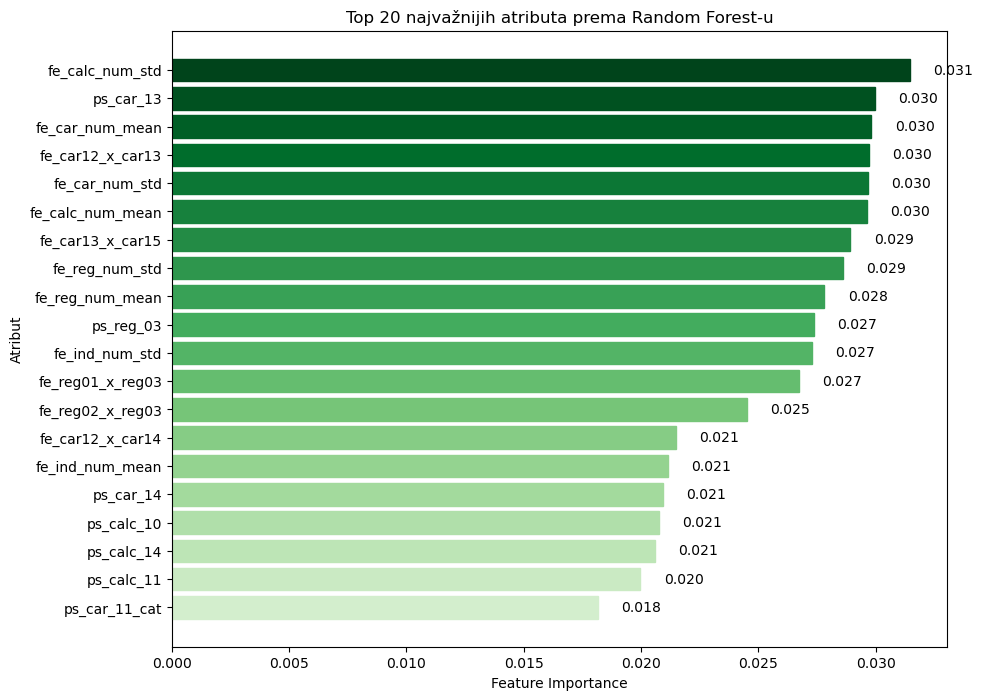

In [56]:
top_n_plot = 20
top_rf = rf_importances.head(top_n_plot).sort_values(by="Importance")

plt.figure(figsize=(10, 8))
bars = plt.barh(top_rf["Feature"], top_rf["Importance"])

colors = plt.cm.Greens(np.linspace(0.2, 1, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)
    
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}", va='center')

plt.title("Top 20 najvažnijih atributa prema Random Forest-u")
plt.xlabel("Feature Importance")
plt.ylabel("Atribut")

plt.show()

In [57]:
top_k_features_rf = rf_importances.head(30)["Feature"].tolist()

print("Top atributi prema Random Forest metodi:")
print(top_k_features_rf)

Top atributi prema Random Forest metodi:
['fe_calc_num_std', 'ps_car_13', 'fe_car_num_mean', 'fe_car12_x_car13', 'fe_car_num_std', 'fe_calc_num_mean', 'fe_car13_x_car15', 'fe_reg_num_std', 'fe_reg_num_mean', 'ps_reg_03', 'fe_ind_num_std', 'fe_reg01_x_reg03', 'fe_reg02_x_reg03', 'fe_car12_x_car14', 'fe_ind_num_mean', 'ps_car_14', 'ps_calc_10', 'ps_calc_14', 'ps_calc_11', 'ps_car_11_cat', 'ps_ind_03', 'ps_calc_03', 'ps_calc_02', 'ps_calc_01', 'ps_ind_15', 'ps_calc_13', 'ps_calc_08', 'ps_calc_07', 'ps_calc_06', 'ps_calc_09']


In [58]:
X_train_embedded = X_train_fe[top_k_features_rf].copy()
X_test_embedded = X_test_fe[top_k_features_rf].copy()

print("Originalni FE dataset:", X_train_fe.shape)
print("Dataset nakon embedded metode:", X_train_embedded.shape)

Originalni FE dataset: (476169, 136)
Dataset nakon embedded metode: (476169, 30)


Rezultati embedded metode pokazuju da pojedini atributi kreirani u fazi feature engineering-a imaju značajan doprinos modelu prema proceni Random Forest-a, što ukazuje da ručno konstruisani agregati i proizvodi atributa mogu nositi korisnu prediktivnu informaciju.

## 6.3 Wrapper metoda 

Wrapper metode selekcije atributa zasnivaju se na evaluaciji performansi konkretnog modela. Za razliku od filter i embedded pristupa, kvalitet atributa se ovde procenjuje kroz njihov direktan uticaj na prediktivni model.

U radu je korišćena metoda RFE (Recursive Feature Elimination) u kombinaciji sa logističkom regresijom. RFE iterativno uklanja najmanje značajne atribute na osnovu koeficijenata modela, pri čemu se model ponovo trenira nakon svakog koraka eliminacije.

U poređenju sa forward selection i backward elimination , RFE se pokazuje kao efikasniji i stabilniji pristup, jer omogućava sistematsko uklanjanje manje relevantnih atributa uz razumnu brzinu izvršavanja. 

In [59]:
# Primena RFE metode nad svim atributima iz FE skupa
all_features = X_train_fe_sc.columns.tolist()

print(f"Broj kandidata za RFE: {len(all_features)}")

Broj kandidata za RFE: 136


In [60]:
# Koristimo skalirani dataset za logističku regresiju
X_train_rfe = X_train_fe_sc[all_features].copy() #pomocni skup za RFE
X_test_rfe = X_test_fe_sc[all_features].copy()

In [61]:
rfe = RFE(
    estimator=LogisticRegression(max_iter=1000, random_state=7),
    n_features_to_select=30,
    step=1
)

rfe.fit(X_train_rfe, y_train)

,estimator,LogisticRegre...andom_state=7)
,n_features_to_select,30
,step,1
,verbose,0
,importance_getter,'auto'
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1


In [62]:
selected_features_rfe = X_train_rfe.columns[rfe.support_].tolist()  # Izdvajanje atributa koje je RFE zadržao

print("Izabrani atributi (RFE):")
print(selected_features_rfe)

Izabrani atributi (RFE):
['ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_15', 'ps_ind_17_bin', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_11_cat', 'ps_car_14', 'ps_car_15', 'ps_car_03_cat_missing', 'ps_car_05_cat_missing', 'ps_reg_03_missing', 'ps_car_14_missing', 'ps_ind_05_cat_0.0', 'ps_ind_05_cat_2.0', 'ps_ind_05_cat_4.0', 'ps_ind_05_cat_6.0', 'ps_car_01_cat_7.0', 'ps_car_01_cat_11.0', 'ps_car_07_cat_0.0', 'ps_car_09_cat_0.0', 'ps_car_09_cat_2.0', 'fe_missing_count', 'fe_car_num_mean', 'fe_ind_num_std', 'fe_car_num_std', 'fe_reg01_x_reg03', 'fe_reg02_x_reg03', 'fe_car12_x_car14']


In [63]:
X_train_wrapper = X_train_fe_sc[selected_features_rfe].copy()
X_test_wrapper = X_test_fe_sc[selected_features_rfe].copy()

print("Originalni FE dataset:", X_train_fe_sc.shape)
print("Dataset nakon wrapper metode:", X_train_wrapper.shape)

Originalni FE dataset: (476169, 136)
Dataset nakon wrapper metode: (476169, 30)


Wrapper metoda predstavlja dodatni korak u selekciji atributa, pri čemu se izbor zasniva na zajedničkom uticaju atributa na performanse konkretnog modela. Za razliku od filter i embedded metode, wrapper metoda uzima u obzir interakcije između atributa kroz iterativno treniranje modela, ali je računski zahtevnija i zavisi od izbora osnovnog modela.

## 6.4 Poređenje rezultata filter, embedded i wrapper metoda za izbor atributa

U nastavku je prikazano poređenje atributa izdvojenih primenom filter, embedded i wrapper pristupa.

In [64]:
set_filter = set(top_k_features_filter)
set_embedded = set(top_k_features_rf)
set_wrapper = set(selected_features_rfe)

In [65]:
presek_svi = set_filter & set_embedded & set_wrapper
presek_filter_embedded = set_filter & set_embedded
presek_filter_wrapper = set_filter & set_wrapper
presek_embedded_wrapper = set_embedded & set_wrapper

In [66]:
print("Presek sve tri:", len(presek_svi))
print("Presek filter i embedded:", len(presek_filter_embedded))
print("Presek filter i wrapper:", len(presek_filter_wrapper))
print("Presek embedded i wrapper:", len(presek_embedded_wrapper))

Presek sve tri: 0
Presek filter i embedded: 0
Presek filter i wrapper: 9
Presek embedded i wrapper: 10


Dobijeni rezultati pokazuju da ne postoji potpun presek između sve tri metode selekcije, što je očekivano jer svaka metoda procenjuje značaj atributa iz drugačijeg ugla. Filter metoda meri statističku povezanost atributa sa ciljnom promenljivom nezavisno od modela, embedded metoda procenjuje doprinos atributa tokom treniranja Random Forest modela, dok wrapper metoda optimizuje izbor atributa u odnosu na performanse logističke regresije.

Na osnovu poređenja formirana su dva kandidata za dalju analizu: prvi obuhvata atribute koji su izdvojeni od najmanje dve metode, dok drugi obuhvata uniju svih atributa koje je izdvojila makar jedna metoda.

In [67]:
# Formiranje tabele poređenja atributa izdvojenih različitim metodama
comparison_df = pd.DataFrame({
    "Atribut": sorted(set_filter | set_embedded | set_wrapper)
})

comparison_df["Filter"] = comparison_df["Atribut"].isin(set_filter)
comparison_df["Embedded"] = comparison_df["Atribut"].isin(set_embedded)
comparison_df["Wrapper"] = comparison_df["Atribut"].isin(set_wrapper)

comparison_df["Broj_metoda"] = (
    comparison_df["Filter"].astype(int) +
    comparison_df["Embedded"].astype(int) +
    comparison_df["Wrapper"].astype(int)
)

comparison_df = comparison_df.sort_values(
    by=["Broj_metoda", "Atribut"],
    ascending=[False, True]
).reset_index(drop=True)

comparison_df.head(50)

,Atribut,Filter,Embedded,Wrapper,Broj_metoda
0,fe_car12_x_car14,False,True,True,2
1,fe_car_num_mean,False,True,True,2
2,fe_car_num_std,False,True,True,2
3,fe_ind_num_std,False,True,True,2
4,fe_reg01_x_reg03,False,True,True,2
5,fe_reg02_x_reg03,False,True,True,2
6,ps_car_01_cat_11.0,True,False,True,2
7,ps_car_01_cat_7.0,True,False,True,2
8,ps_car_03_cat_missing,True,False,True,2
9,ps_car_05_cat_missing,True,False,True,2


In [68]:
# Atributi izdvojeni od najmanje dve metode
features_2plus = comparison_df.loc[
    comparison_df["Broj_metoda"] >= 2, "Atribut"
].tolist()

# Atributi izdvojeni od najmanje jedne metode
features_1plus = comparison_df.loc[
    comparison_df["Broj_metoda"] >= 1, "Atribut"
].tolist()

print("Broj atributa koji se pojavljuju u bar 2 metode:", len(features_2plus))
print("Atributi 2+ metode:")
print(sorted(features_2plus))

print("\nBroj atributa koji se pojavljuju u bar 1 metodi:", len(features_1plus))
print("Atributi 1+ metoda:")
print(sorted(features_1plus))

Broj atributa koji se pojavljuju u bar 2 metode: 19
Atributi 2+ metode:
['fe_car12_x_car14', 'fe_car_num_mean', 'fe_car_num_std', 'fe_ind_num_std', 'fe_reg01_x_reg03', 'fe_reg02_x_reg03', 'ps_car_01_cat_11.0', 'ps_car_01_cat_7.0', 'ps_car_03_cat_missing', 'ps_car_05_cat_missing', 'ps_car_09_cat_0.0', 'ps_car_09_cat_2.0', 'ps_car_11_cat', 'ps_car_14', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_15', 'ps_reg_03', 'ps_reg_03_missing']

Broj atributa koji se pojavljuju u bar 1 metodi: 71
Atributi 1+ metoda:
['fe_calc_num_mean', 'fe_calc_num_std', 'fe_car12_x_car13', 'fe_car12_x_car14', 'fe_car13_x_car15', 'fe_car_num_mean', 'fe_car_num_std', 'fe_ind_num_mean', 'fe_ind_num_std', 'fe_missing_count', 'fe_reg01_x_reg03', 'fe_reg02_x_reg03', 'fe_reg_num_mean', 'fe_reg_num_std', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_13', 'ps_calc_14', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bi

In [69]:
# Dataset sa atributima izdvojenim od najmanje dve metode
X_train_fs_2plus = X_train_fe[features_2plus].copy()
X_test_fs_2plus = X_test_fe[features_2plus].copy()

X_train_fs_2plus_sc = X_train_fe_sc[features_2plus].copy()
X_test_fs_2plus_sc = X_test_fe_sc[features_2plus].copy()

# Dataset sa atributima izdvojenim od najmanje jedne metode
X_train_fs_1plus = X_train_fe[features_1plus].copy()
X_test_fs_1plus = X_test_fe[features_1plus].copy()

X_train_fs_1plus_sc = X_train_fe_sc[features_1plus].copy()
X_test_fs_1plus_sc = X_test_fe_sc[features_1plus].copy()

print("FE dataset:", X_train_fe.shape)
print("FS 2+ dataset:", X_train_fs_2plus.shape)
print("FS 1+ dataset:", X_train_fs_1plus.shape)

FE dataset: (476169, 136)
FS 2+ dataset: (476169, 19)
FS 1+ dataset: (476169, 71)


Na osnovu broja metoda koje su izdvojile određeni atribut, formirana su dva redukovana skupa atributa. Prvi skup obuhvata atribute potvrđene od  najmanje dve metode selekcije i predstavlja stroži kriterijum izbora atributa. Drugi skup obuhvata sve atribute izdvojene makar jednom metodom selekcije i predstavlja blaži kriterijum izbora. Ova dva skupa biće korišćena u nastavku rada kako bi se ispitao uticaj različitih kriterijuma selekcije atributa na performanse modela.

### 6.5 Uticaj selekcije atributa na performanse modela

Logistička regresija nad skupom FS_2plus 

In [70]:
# Inicijalizacija modela
lr_fs_2plus = LogisticRegression(max_iter=1000, random_state=7)
# Treniranje modela na skaliranim podacima 
lr_fs_2plus.fit(X_train_fs_2plus_sc, y_train)
# Predikcija verovatnoća (bitno za AUC)
y_pred_lr_fs_2plus = lr_fs_2plus.predict_proba(X_test_fs_2plus_sc)[:, 1]
# Izračunavanje AUC metrike
auc_lr_fs_2plus, gini_lr_fs_2plus = evaluate_model("Logistic Regression (fs_2plus)", y_test, y_pred_lr_fs_2plus)

Logistic Regression (fs_2plus)
AUC:  0.6149
Gini: 0.2299


Logistička regresija nad skupom FS_1plus

In [71]:
# Inicijalizacija modela
lr_fs_1plus = LogisticRegression(max_iter=1000, random_state=7)
# Treniranje modela na skaliranim podacima 
lr_fs_1plus.fit(X_train_fs_1plus_sc, y_train)
# Predikcija verovatnoća (bitno za AUC)
y_pred_lr_fs_1plus = lr_fs_1plus.predict_proba(X_test_fs_1plus_sc)[:, 1]
# Izračunavanje AUC metrike
auc_lr_fs_1plus, gini_lr_fs_1plus = evaluate_model("Logistic Regression (fs_1plus)", y_test, y_pred_lr_fs_1plus)

Logistic Regression (fs_1plus)
AUC:  0.6402
Gini: 0.2805


KNN nad skupom FS_2plus

In [72]:
# Inicijalizacija modela
knn_fs_2plus = KNeighborsClassifier(n_neighbors=5)
# Treniranje na skaliranim podacima
knn_fs_2plus.fit(X_train_fs_2plus_sc, y_train)
# Predikcija verovatnoća
y_pred_knn_fs_2plus = knn_fs_2plus.predict_proba(X_test_fs_2plus_sc)[:, 1]
# Izračunavanje AUC metrike
auc_knn_fs_2plus, gini_knn_fs_2plus = evaluate_model("KNN (fs_2plus)", y_test, y_pred_knn_fs_2plus)

KNN (fs_2plus)
AUC:  0.5083
Gini: 0.0166


KNN nad skupom FS_1plus

In [73]:
# Inicijalizacija modela
knn_fs_1plus = KNeighborsClassifier(n_neighbors=5)
# Treniranje na skaliranim podacima
knn_fs_1plus.fit(X_train_fs_1plus_sc, y_train)
# Predikcija verovatnoća
y_pred_knn_fs_1plus = knn_fs_1plus.predict_proba(X_test_fs_1plus_sc)[:, 1]
# Izračunavanje AUC metrike
auc_knn_fs_1plus, gini_knn_fs_1plus = evaluate_model("KNN (fs_1plus)",y_test,y_pred_knn_fs_1plus)

KNN (fs_1plus)
AUC:  0.5202
Gini: 0.0405


Stablo odlučivanja nad FS_2plus

In [74]:
# Inicijalizacija modela
dt_fs_2plus = DecisionTreeClassifier(random_state=7)
# Treniranje na neskaliranim podacima
dt_fs_2plus.fit(X_train_fs_2plus, y_train)
# Predikcija verovatnoća
y_pred_dt_fs_2plus = dt_fs_2plus.predict_proba(X_test_fs_2plus)[:, 1]
# Izračunavanje AUC metrike
auc_dt_fs_2plus, gini_dt_fs_2plus = evaluate_model("Decision Tree (fs_2plus)", y_test, y_pred_dt_fs_2plus)

Decision Tree (fs_2plus)
AUC:  0.5048
Gini: 0.0097


Stablo odlučivanja nad FS_1plus

In [75]:
# Inicijalizacija modela
dt_fs_1plus = DecisionTreeClassifier(random_state=7)
# Treniranje na neskaliranim podacima
dt_fs_1plus.fit(X_train_fs_1plus, y_train)
# Predikcija verovatnoća
y_pred_dt_fs_1plus = dt_fs_1plus.predict_proba(X_test_fs_1plus)[:, 1]
# Izračunavanje AUC metrike
auc_dt_fs_1plus, gini_dt_fs_1plus = evaluate_model("Decision Tree (fs_1plus)", y_test, y_pred_dt_fs_1plus)

Decision Tree (fs_1plus)
AUC:  0.5058
Gini: 0.0117


In [76]:
comparison_results = pd.DataFrame({
    "Model": [
        "LogReg (fe)",
        "LogReg (fs_2plus)",
        "LogReg (fs_1plus)",
        "KNN (fe)",
        "KNN (fs_2plus)",
        "KNN (fs_1plus)",
        "Decision Tree (fe)",
        "Decision Tree (fs_2plus)",
        "Decision Tree (fs_1plus)"
    ],
    "AUC": [
        auc_lr_fe, auc_lr_fs_2plus, auc_lr_fs_1plus,
        auc_knn_fe, auc_knn_fs_2plus, auc_knn_fs_1plus,
        auc_dt_fe, auc_dt_fs_2plus, auc_dt_fs_1plus
    ],
    "Gini": [
        gini_lr_fe, gini_lr_fs_2plus, gini_lr_fs_1plus,
        gini_knn_fe, gini_knn_fs_2plus, gini_knn_fs_1plus,
        gini_dt_fe, gini_dt_fs_2plus, gini_dt_fs_1plus
    ]
})

comparison_results = comparison_results.sort_values(by="AUC", ascending=False).reset_index(drop=True)
comparison_results

,Model,AUC,Gini
0,LogReg (fe),0.640551,0.281102
1,LogReg (fs_1plus),0.640244,0.280488
2,LogReg (fs_2plus),0.614937,0.229874
3,KNN (fe),0.520254,0.040507
4,KNN (fs_1plus),0.520239,0.040478
5,KNN (fs_2plus),0.508287,0.016573
6,Decision Tree (fe),0.508282,0.016564
7,Decision Tree (fs_1plus),0.505830,0.011661
8,Decision Tree (fs_2plus),0.504848,0.009696


Rezultati pokazuju da različiti kriterijumi selekcije atributa utiču na performanse modela, ali da u ovom slučaju kompletan skup atributa nakon feature engineering faze (`fe`) daje najbolje rezultate kod svih posmatranih baseline modela. Stroži kriterijum selekcije (`fs_2plus`) dovodi do najvećeg smanjenja dimenzionalnosti, ali istovremeno i do primetnijeg pada performansi, što ukazuje na gubitak dela korisnih informacija.

Blaži kriterijum selekcije (`fs_1plus`) daje rezultate koji su veoma bliski originalnom `fe` skupu, ali ga u ovom eksperimentu ipak ne nadmašuje. To pokazuje da selekcija atributa može doprineti pojednostavljenju modela, ali ne mora nužno dovesti i do poboljšanja performansi.

Na osnovu dobijenih rezultata može se zaključiti da su linearni i distance-based modeli osetljiviji na smanjenje broja atributa, dok model zasnovan na stablu odlučivanja pokazuje nešto veću robusnost, iako i kod njega kompletan skup atributa (`fe`) ostvaruje najbolji rezultat.

## 7. Advanced Models

U ovoj fazi rada primenjeni su napredniji ansambl modeli sa ciljem postizanja boljih performansi u odnosu na prethodno razmatrane baseline algoritme. Izabrani su Random Forest i XGBoost, jer predstavljaju snažne modele za klasifikacione zadatke i mogu uspešno da modeluju složene nelinearne odnose među atributima.

Kako bi poređenje bilo metodološki ispravno, oba modela biće evaluirana nad tri skupa atributa:
- kompletnim skupom atributa nakon feature engineering faze,
- skupom atributa izdvojenim od strane najmanje jedne metode selekcije (fs_1plus),
- skupom atributa izdvojenim od strane najmanje dve metode selekcije (fs_2plus).


### 7.1 Random Forest

Random Forest predstavlja ansambl metodu zasnovanu na većem broju stabala odlučivanja, gde svako stablo daje pojedinačnu predikciju, a konačna odluka donosi se agregacijom njihovih rezultata.
Jedna od ključnih prednosti ovog algoritma jeste sposobnost modelovanja nelinearnih odnosa i interakcija između atributa, kao i robusnost na šum u podacima. Takođe, Random Forest nije osetljiv na skalu atributa, pa se trenira nad neskaliranim podacima.

Random Forest model je evaluiran nad tri prethodno definisana skupa atributa.
Evaluacija se vrši korišćenjem stratifikovane k-fold kros validacije sa metrikom ROC-AUC.

In [77]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

In [78]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=50,
        random_state=7,
        n_jobs=-1
    ))
])

In [79]:
# all
rf_cv_fe = cross_val_score(
    rf_pipeline,
    X_train_fe,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

# fs_1+
rf_cv_fs_1plus = cross_val_score(
    rf_pipeline,
    X_train_fs_1plus,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

# FS_2+
rf_cv_fs_2plus = cross_val_score(
    rf_pipeline,
    X_train_fs_2plus,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

In [80]:
print("Random Forest CV AUC (fe):", rf_cv_fe.mean())
print("Random Forest CV AUC (fs_1plus):", rf_cv_fs_1plus.mean())
print("Random Forest CV AUC (fs_2plus):", rf_cv_fs_2plus.mean())

Random Forest CV AUC (fe): 0.5726558903170964
Random Forest CV AUC (fs_1plus): 0.5677444262284606
Random Forest CV AUC (fs_2plus): 0.5522682850280198


In [83]:
# FE
rf_pipeline.fit(X_train_fe, y_train)
y_pred_rf_fe = rf_pipeline.predict_proba(X_test_fe)[:, 1]

# FS 1+
rf_pipeline.fit(X_train_fs_1plus, y_train)
y_pred_rf_fs_1plus = rf_pipeline.predict_proba(X_test_fs_1plus)[:, 1]

# FS 2+
rf_pipeline.fit(X_train_fs_2plus, y_train)
y_pred_rf_fs_2plus = rf_pipeline.predict_proba(X_test_fs_2plus)[:, 1]

In [84]:
auc_rf_fe, gini_rf_fe = evaluate_model("RF (fe)", y_test, y_pred_rf_fe)
auc_rf_fs_1plus, gini_rf_fs_1plus = evaluate_model("RF (fs_1plus)", y_test, y_pred_rf_fs_1plus)
auc_rf_fs_2plus, gini_rf_fs_2plus = evaluate_model("RF (fs_2plus)", y_test, y_pred_rf_fs_2plus)

RF (fe)
AUC:  0.5749
Gini: 0.1498
RF (fs_1plus)
AUC:  0.5746
Gini: 0.1491
RF (fs_2plus)
AUC:  0.5512
Gini: 0.1024


Rezultati pokazuju da Random Forest bolje reaguje na umerenu nego na agresivnu selekciju atributa. Skup fs_2plus dovodi do pada performansi, dok fs_1plus daje najbolji balans između redukcije dimenzionalnosti i očuvanja prediktivnog signala.

### 7.2 XGBoost

XGBoost predstavlja ansambl metodu zasnovanu na sekvencijalnoj izgradnji stabala odlučivanja, pri čemu svako naredno stablo pokušava da ispravi greške prethodnih. Jedna od ključnih prednosti ovog algoritma jeste sposobnost modelovanja složenih nelinearnih odnosa i interakcija između atributa, uz visoku fleksibilnost i dobre performanse na klasifikacionim zadacima. Kao i Random Forest, XGBoost nije osetljiv na skalu atributa, pa se trenira nad neskaliranim podacima.

XGBoost model je evaluiran nad tri prethodno definisana skupa atributa. Evaluacija se vrši korišćenjem stratifikovane k-fold kros validacije sa metrikom ROC-AUC.

In [85]:
xgb_pipeline = Pipeline([
    ("model", XGBClassifier(
        n_estimators=50,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=7,
        n_jobs=-1
    ))
])

In [86]:
X_train_fe = X_train_fe.astype(float)
X_test_fe = X_test_fe.astype(float)

X_train_fs_1plus = X_train_fs_1plus.astype(float)
X_test_fs_1plus = X_test_fs_1plus.astype(float)

X_train_fs_2plus = X_train_fs_2plus.astype(float)
X_test_fs_2plus = X_test_fs_2plus.astype(float)

In [87]:
# svi atributi
xgb_cv_fe = cross_val_score(
    xgb_pipeline,
    X_train_fe,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

# fs_1plus
xgb_cv_fs_1plus = cross_val_score(
    xgb_pipeline,
    X_train_fs_1plus,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

# fs_2plus
xgb_cv_fs_2plus = cross_val_score(
    xgb_pipeline,
    X_train_fs_2plus,
    y_train,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

In [88]:
print("XGBoost CV AUC (fe):", xgb_cv_fe.mean())
print("XGBoost CV AUC (fs_1plus):", xgb_cv_fs_1plus.mean())
print("XGBoost CV AUC (fs_2plus):", xgb_cv_fs_2plus.mean())

XGBoost CV AUC (fe): 0.6333254350579809
XGBoost CV AUC (fs_1plus): 0.6309591040248042
XGBoost CV AUC (fs_2plus): 0.6125135998070663


In [89]:
# FE
xgb_pipeline.fit(X_train_fe, y_train)
y_pred_xgb_fe = xgb_pipeline.predict_proba(X_test_fe)[:, 1]

# FS 1+
xgb_pipeline.fit(X_train_fs_1plus, y_train)
y_pred_xgb_fs_1plus = xgb_pipeline.predict_proba(X_test_fs_1plus)[:, 1]

# FS 2+
xgb_pipeline.fit(X_train_fs_2plus, y_train)
y_pred_xgb_fs_2plus = xgb_pipeline.predict_proba(X_test_fs_2plus)[:, 1]

In [90]:
auc_xgb_fe, gini_xgb_fe = evaluate_model("XGBoost (fe)", y_test, y_pred_xgb_fe)
auc_xgb_fs_1plus, gini_xgb_fs_1plus = evaluate_model("XGBoost (fs_1plus)", y_test, y_pred_xgb_fs_1plus)
auc_xgb_fs_2plus, gini_xgb_fs_2plus = evaluate_model("XGBoost (fs_2plus)", y_test, y_pred_xgb_fs_2plus)

XGBoost (fe)
AUC:  0.6453
Gini: 0.2905
XGBoost (fs_1plus)
AUC:  0.6429
Gini: 0.2858
XGBoost (fs_2plus)
AUC:  0.6152
Gini: 0.2305


Rezultati XGBoost modela pokazuju bolje performanse u odnosu na Random Forest, što ukazuje na to da boosting pristup uspešnije modeluje složenije nelinearne odnose u podacima.

Može se uočiti da kompletan skup atributa (`fe`) ostvaruje najbolje performanse, dok skup `fs_1plus` daje blago slabije, ali i dalje konkurentne rezultate. To ukazuje da je redukcijom broja atributa moguće zadržati relativno visok kvalitet modela.

Sa druge strane, kod skupa fs_2plus vidi se pad performansi, što ukazuje da je stroža selekcija uklonila i određene atribute koji su bili značajni za model.

## 8. Optimizacija hiperparametara modela

U prethodnim koracima izdvojeni su skupovi atributa `fs_1plus` i `fe`, jer su na dosadašnjim eksperimentima dali najbolje rezultate. Pošto je razlika između ova dva skupa bila mala, u ovoj fazi se radi optimizacija hiperparametara XGBoost modela nad oba skupa, kako bi se proverilo da li se dodatnim podešavanjem može postići još bolje rešenje i pouzdanija generalizacija.

In [91]:
xgb_tuning_pipeline_fs_1plus = Pipeline([
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=7,
        n_jobs=-1
    ))
])

Definisan je pipeline koji sadrži XGBoost klasifikator za fs_1plus. 

In [92]:
param_distributions = {
    "model__n_estimators": [50, 100, 150, 200, 250, 300],
    "model__max_depth": [3, 4, 5, 6, 7, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__gamma": [0, 0.1, 0.2, 0.3, 0.5]
}

Definisan je skup hiperparametara koji obuhvata broj stabala, dubinu stabala, brzinu učenja, regularizaciju itd.

In [93]:
xgb_random_search_fs_1plus = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline_fs_1plus,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    verbose=2,
    random_state=7,
    n_jobs=-1
)

Za optimizaciju hiperparametara korišćen je RandomizedSearchCV, jer omogućava efikasniju pretragu većeg broja kombinacija u odnosu na pretragu svih mogućnosti. Evaluacija kandidata vršena je stratifikovanom kros validacijom sa metrikom ROC-AUC.

In [94]:
xgb_random_search_fs_1plus.fit(X_train_fs_1plus, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.7, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,7
,error_score,nan


In [95]:
print("Najbolji parametri za fs_1plus:")
print(xgb_random_search_fs_1plus.best_params_)

print("\nNajbolji CV AUC za fs_1plus:")
print(xgb_random_search_fs_1plus.best_score_)

Najbolji parametri za fs_1plus:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}

Najbolji CV AUC za fs_1plus:
0.6354912307257219


In [96]:
best_xgb_model_fs_1plus = xgb_random_search_fs_1plus.best_estimator_

In [97]:
best_xgb_model_fs_1plus

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8


In [98]:
y_pred_xgb_tuned_fs_1plus = best_xgb_model_fs_1plus.predict_proba(X_test_fs_1plus)[:, 1]

In [99]:
auc_xgb_tuned_fs_1plus, gini_xgb_tuned_fs_1plus = evaluate_model("XGBoost tuned (fs_1plus)", y_test, y_pred_xgb_tuned_fs_1plus)

XGBoost tuned (fs_1plus)
AUC:  0.6475
Gini: 0.2949


In [100]:
xgb_tuning_pipeline_fe = Pipeline([
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=7,
        n_jobs=-1
    ))
])

Definisan je pipeline koji sadrži XGBoost klasifikator za fe .

In [101]:
xgb_random_search_fe = RandomizedSearchCV(
    estimator=xgb_tuning_pipeline_fe,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_strategy,
    verbose=2,
    random_state=7,
    n_jobs=-1
)

In [102]:
xgb_random_search_fe.fit(X_train_fe, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.7, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,7
,error_score,nan


In [103]:
print("Najbolji parametri za FE:")
print(xgb_random_search_fe.best_params_)

print("\nNajbolji CV AUC za FE:")
print(xgb_random_search_fe.best_score_)

Najbolji parametri za FE:
{'model__subsample': 0.9, 'model__n_estimators': 150, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0.2, 'model__colsample_bytree': 0.8}

Najbolji CV AUC za FE:
0.6372061039717741


In [104]:
best_xgb_model_fe = xgb_random_search_fe.best_estimator_

y_pred_xgb_tuned_fe = best_xgb_model_fe.predict_proba(X_test_fe)[:, 1]

auc_xgb_tuned_fe, gini_xgb_tuned_fe = evaluate_model(
    "XGBoost tuned (fe)", y_test, y_pred_xgb_tuned_fe
)

XGBoost tuned (fe)
AUC:  0.6503
Gini: 0.3006


In [114]:
xgb_tuning_comparison_fs_1plus = pd.DataFrame({
    "Model": ["XGBoost (fs_1plus)", "XGBoost tuned (fs_1plus)"],
    "AUC": [auc_xgb_fs_1plus, auc_xgb_tuned_fs_1plus],
    "Gini": [gini_xgb_fs_1plus, gini_xgb_tuned_fs_1plus]
})

xgb_tuning_comparison_fs_1plus

,Model,AUC,Gini
0,XGBoost (fs_1plus),0.642904,0.285808
1,XGBoost tuned (fs_1plus),0.647464,0.294928


In [107]:
xgb_tuning_comparison_fe = pd.DataFrame({
    "Model": ["XGBoost (fe)", "XGBoost tuned (fe)"],
    "AUC": [auc_xgb_fe, auc_xgb_tuned_fe],
    "Gini": [gini_xgb_fe, gini_xgb_tuned_fe]
})

xgb_tuning_comparison_fe

,Model,AUC,Gini
0,XGBoost (fe),0.645273,0.290547
1,XGBoost tuned (fe),0.650292,0.300585


Poređenje rezultata pokazuje da je optimizacija hiperparametara unapredila performanse XGBoost modela nad oba skupa atributa. 
Može se uočiti da optimizovani model nad skupom `fe` ostvaruje nešto bolje rezultate od optimizovanog modela nad skupom `fs_1plus`. To ukazuje da XGBoost uspešnije koristi informacije iz kompletnog skupa atributa nakon feature engineering faze, dok redukovani skup `fs_1plus` i dalje daje veoma konkurentne rezultate.

<Figure size 1000x600 with 0 Axes>

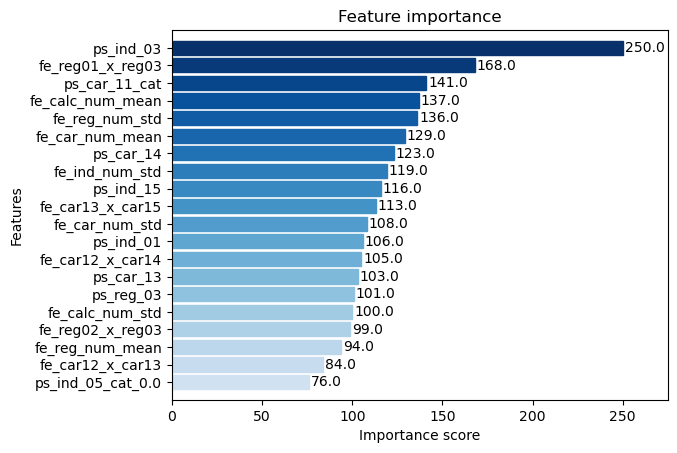

In [115]:
# plt.figure(figsize=(10,6))
# plot_importance(best_xgb_model.named_steps["model"], max_num_features=20)
# plt.show()

plt.figure(figsize=(10,6))

ax = plot_importance(best_xgb_model_fe.named_steps["model"], max_num_features=20, height=0.8)

bars = ax.patches
colors = plt.cm.Blues(np.linspace(0.2, 1.0, len(bars)))

for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.grid(False)

plt.show()


Prikaz značajnosti atributa odnosi se na optimizovani XGBoost model treniran nad skupom `fe`, koji je ostvario najbolje performanse u celokupnoj analizi. Može se uočiti da među najvažnijim atributima postoje i atributi nastali tokom feature engineering faze, što potvrđuje da su prethodne transformacije podataka bile korisne i da su doprinele kvalitetu finalnog modela.

## 9. Poređenje modela

U ovom poglavlju vrši se  poređenje performansi različitih modela. Cilj je identifikovati koji model i koji skup atributa daju najbolje rezultate u zadatom problemu klasifikacije.

Modeli su trenirani i evaluirani na različitim skupovima atributa:
- kompletan skup atributa nakon feature engineering-a (fe)
- skup atributa izabranih od strane najmanje jedne metode selekcije (fs_1plus)
- skup atributa izabranih od strane najmanje dve metode selekcije (fs_2plus)

U poređenje su uključeni:
- osnovni (baseline) modeli: Logistic Regression, KNN i Decision Tree
- ansambl modeli: Random Forest i XGBoost
- optimizovani model: XGBoost dobijen podešavanjem hiperparametara

Performanse modela evaluirane su korišćenjem ROC-AUC i Gini koeficijenta, pri čemu Gini predstavlja glavnu metriku evaluacije u ovom zadatku.

### 9.1 Tabelarno poređenje performansi modela

U nastavku je prikazano završno poređenje svih relevantnih modela razvijenih u radu. 
U tabeli su prikazani rezultati osnovnih modela, ansambl modela i optimizovanog XGBoost modela, pri čemu se poređenje vrši na osnovu ROC-AUC i Gini koeficijenta.

In [120]:
model_comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (fe)",
        "Logistic Regression (fs_1plus)",
        "Logistic Regression (fs_2plus)",
        "KNN (fe)",
        "KNN (fs_1plus)",
        "KNN (fs_2plus)",
        "Decision Tree (fe)",
        "Decision Tree (fs_1plus)",
        "Decision Tree (fs_2plus)",
        "Random Forest (fe)",
        "Random Forest (fs_1plus)",
        "Random Forest (fs_2plus)",
        "XGBoost (fe)",
        "XGBoost (fs_1plus)",
        "XGBoost (fs_2plus)",
        "XGBoost tuned (fs_1plus)",
        "XGBoost tuned (fe)"
    ],
    "AUC": [
        auc_lr_fe,
        auc_lr_fs_1plus,
        auc_lr_fs_2plus,
        auc_knn_fe,
        auc_knn_fs_1plus,
        auc_knn_fs_2plus,
        auc_dt_fe,
        auc_dt_fs_1plus,
        auc_dt_fs_2plus,
        auc_rf_fe,
        auc_rf_fs_1plus,
        auc_rf_fs_2plus,
        auc_xgb_fe,
        auc_xgb_fs_1plus,
        auc_xgb_fs_2plus,
        auc_xgb_tuned_fs_1plus,
        auc_xgb_tuned_fe
    ],
    "Gini": [
        gini_lr_fe,
        gini_lr_fs_1plus,
        gini_lr_fs_2plus,
        gini_knn_fe,
        gini_knn_fs_1plus,
        gini_knn_fs_2plus,
        gini_dt_fe,
        gini_dt_fs_1plus,
        gini_dt_fs_2plus,
        gini_rf_fe,
        gini_rf_fs_1plus,
        gini_rf_fs_2plus,
        gini_xgb_fe,
        gini_xgb_fs_1plus,
        gini_xgb_fs_2plus,
        gini_xgb_tuned_fs_1plus,
        gini_xgb_tuned_fe
    ]
})
model_comparison_df = model_comparison_df.sort_values(by="AUC", ascending=False).reset_index(drop=True)

model_comparison_df.style.format({
    "AUC": "{:.4f}",
    "Gini": "{:.4f}"
})

model_comparison_df

,Model,AUC,Gini
0,XGBoost tuned (fe),0.650292,0.300585
1,XGBoost tuned (fs_1plus),0.647464,0.294928
2,XGBoost (fe),0.645273,0.290547
3,XGBoost (fs_1plus),0.642904,0.285808
4,Logistic Regression (fe),0.640551,0.281102
5,Logistic Regression (fs_1plus),0.640244,0.280488
6,XGBoost (fs_2plus),0.615244,0.230488
7,Logistic Regression (fs_2plus),0.614937,0.229874
8,Random Forest (fe),0.574896,0.149792
9,Random Forest (fs_1plus),0.574558,0.149115


Rezultati pokazuju da optimizovani XGBoost model treniran nad skupom atributa `fe` ostvaruje najbolje performanse među svim analiziranim pristupima. Optimizovani XGBoost model nad skupom `fs_1plus` takođe postiže vrlo dobar rezultat, ali ipak ostaje nešto ispod performansi modela treniranog nad kompletnim skupom atributa. To ukazuje da XGBoost uspešno koristi dodatne informacije iz skupa atributa nakon feature engineering faze.

Kod logističke regresije razlika između skupova `fe` i `fs_1plus` je veoma mala, što pokazuje da blaža selekcija atributa u ovom slučaju ne menja značajno kvalitet modela. Kod KNN-a `fe` i `fs_1plus` daju gotovo identične rezultate. 
Uočava se da skup atributa `fs_2plus` konzistentno ostvaruje najslabije performanse kod svih modela, što ukazuje da previše stroga selekcija dovodi do gubitka korisnih informacija iz podataka.

### 9.2 Grafičko poređenje modela

Radi preglednijeg prikaza razlike u performansama, rezultati modela prikazani su i grafički. Na grafiku su prikazane vrednosti Gini koeficijenta za sve modele obuhvaćene završnim poređenjem.

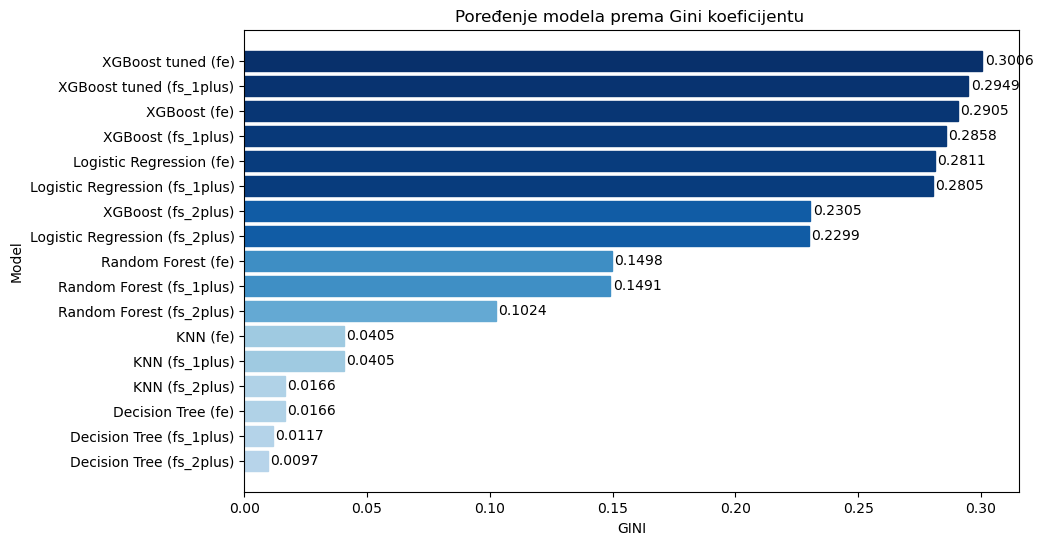

In [121]:
plt.figure(figsize=(10,6))

bars = plt.barh(model_comparison_df["Model"], model_comparison_df["Gini"])

values = model_comparison_df["Gini"].values
norm = (values - values.min()) / (values.max() - values.min())
colors = plt.cm.Blues(0.3 + 0.7 * norm)

for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", va='center')

plt.title("Poređenje modela prema Gini koeficijentu ")
plt.xlabel("GINI")
plt.ylabel("Model")

plt.show()

Grafički prikaz dodatno potvrđuje razliku između posmatranih grupa modela. XGBoost i logistička regresija ostvaruju znatno više vrednosti Gini koeficijenta od Random Forest, KNN i Decision Tree modela, što ukazuje da u podacima postoje obrasci koje ova dva pristupa uspešnije hvataju.

## 10. Finalna evaluacija modela

Na osnovu prethodnih analiza, kao finalni model izdvojen je optimizovani XGBoost model treniran nad skupom atributa `fe`. U nastavku je prikazana njegova završna evaluacija korišćenjem ROC krive.

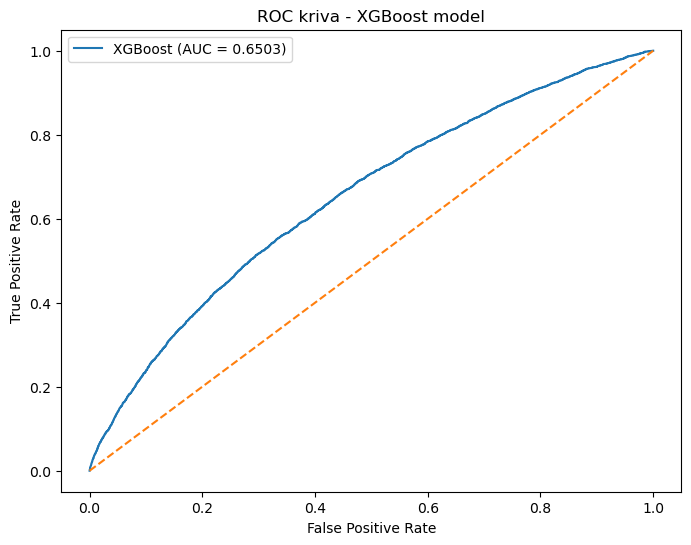

In [116]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb_tuned_fe)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')  # random model

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC kriva - XGBoost model")
plt.legend()

plt.show()

ROC kriva prikazuje odnos između stope tačno pozitivnih i lažno pozitivnih klasifikacija pri različitim pragovima odlučivanja. Dobijena kriva se nalazi iznad dijagonale koja predstavlja nasumično predviđanje, što ukazuje da model uspeva da razlikuje pozitivne i negativne instance bolje od nasumičnog predviđanja.

### 10.1 Zaključak

U okviru ovog rada analiziran je problem binarne klasifikacije primenom različitih modela mašinskog učenja i tehnika obrade podataka. Poseban fokus stavljen je na uticaj feature engineering-a, selekcije atributa i optimizacije hiperparametara na performanse modela.

U radu su testirani osnovni modeli, poput logističke regresije, KNN i stabla odlučivanja, kao i napredniji modeli, uključujući Random Forest i XGBoost. Rezultati su pokazali da je optimizovani XGBoost model na `fe` skupu podataka ostvario najbolje performanse, dok je logistička regresija takođe dala konkurentne rezultate, što ukazuje da u podacima postoje i obrasci koje jednostavniji modeli mogu uspešno da prepoznaju.

Analiziran je i uticaj različitih skupova atributa, pri čemu je pokazano da selekcija atributa može smanjiti dimenzionalnost sa malim gubitkom performansi. Dodatno, optimizacija hiperparametara XGBoost modela dovela je do daljeg unapređenja rezultata.

Na osnovu sprovedene analize može se zaključiti da kombinacija pažljivo pripremljenih atributa, odgovarajuće selekcije i optimizacije najuspešnijeg modela predstavlja ključ za postizanje stabilnih i kvalitetnih rezultata u zadatku klasifikacije. Kao najbolji model rada izdvojen je optimizovani XGBoost model treniran nad `fe` skupom podataka.

In [ ]:
import joblib

final_model_package = {
    "model": best_xgb_model_fe,
    "feature_columns": X_train_fe.columns.tolist()
}

# Save on the disc
joblib.dump(final_model_package, "final_xgboost_fe_model.pkl")

print("Model is saved.")